# 0. Contexto del proyecto
- **Objetivo:** Clasificación multiclase de las etapas del sueño (`Sleep_Stage`: W, N1, N2, N3, R) a partir de señales fisiológicas de Polisomnografía (PSG) y del wearable Empatica E4.
- **Frecuencia de muestreo:** 100 Hz (mediciones cada 10 ms). Un epoch estándar equivale a 30 segundos (3000 muestras).
- **Formato de archivos:** Archivos individuales por paciente con nomenclatura `SXXX_PSG_df.csv` (ej. `S005_PSG_df.csv`, donde `005` es el ID del participante).
- **Esquema de columnas (32 variables):**
  - *Temporal:* `TIMESTAMP`
  - *EEG / EOG / EMG / ECG (PSG):* `C4-M1`, `F4-M1`, `O2-M1`, `Fp1-O2`, `T3 - CZ`, `CZ - T4`, `CHIN`, `E1`, `E2`, `ECG`, `LAT`, `RAT`
  - *Respiratorias y Oximetría (PSG):* `SNORE`, `PTAF`, `FLOW`, `THORAX`, `ABDOMEN`, `SAO2`
  - *Wearable (Empatica E4):* `BVP`, `ACC_X`, `ACC_Y`, `ACC_Z`, `TEMP`, `EDA`, `HR`, `IBI`
  - *Eventos Clínicos (Apneas):* `Obstructive_Apnea`, `Central_Apnea`, `Hypopnea`, `Multiple_Events`
  - *Target:* `Sleep_Stage`
- **Fuente:** DREAMT 2.2.0, disponible en PhysioNet. La copia de Kaggle contiene 68 archivos de pacientes.
- **Anotaciones:** las etapas de sueño fueron anotadas por especialistas cada 30 segundos. Las anotaciones de apnea se conservan en el origen, pero no se incluyen como predictores.

# 1. Carga de datos
Se localizan los CSV y se carga un paciente completo para el análisis exploratorio. El procesamiento de varios pacientes se configura por separado en la sección 3.1.

In [ ]:
import os
import re
import gc
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, **kwargs: x

# Configuración inicial de visualización y advertencias
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

In [ ]:
# 1.1. Detección automática de entorno y listado de archivos
def get_dataset_files(local_data_dir: str = "./data") -> list[Path]:
    """
    Detecta el entorno de ejecución (Kaggle vs Local) y localiza recursivamente
    todos los archivos que coincidan con 'S*_PSG_df.csv'.
    """
    is_kaggle = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or Path('/kaggle/input').exists()
    
    if is_kaggle:
        print("[Entorno detectado] Kaggle Kernel")
        search_root = Path('/kaggle/input')
        files = sorted(list(search_root.rglob('S*_PSG_df.csv')), key=lambda p: p.name)
    else:
        print("[Entorno detectado] Entorno Local")
        local_path = Path(local_data_dir)
        if not local_path.exists():
            local_path = Path(".")
        files = sorted(list(local_path.rglob('S*_PSG_df.csv')), key=lambda p: p.name)
    
    print(f"Total archivos PSG encontrados: {len(files)}")
    return files

def extract_patient_id(file_path: Path | str) -> int:
    """
    Extrae el identificador numérico de paciente desde el nombre de archivo (ej. 'S005_PSG_df.csv' -> 5).
    """
    filename = Path(file_path).name
    match = re.search(r'S(\d+)_PSG_df\.csv', filename, re.IGNORECASE)
    if match:
        return int(match.group(1))
    digits = re.search(r'\d+', filename)
    return int(digits.group(0)) if digits else -1

data_files = get_dataset_files()
if data_files:
    print("Ejemplo de archivos detectados:", [f.name for f in data_files[:5]])

# Función temporal compartida por el EDA y el ETL.
def definir_epochs(df):
    """
    Identifica la alineación a partir de cambios entre etapas válidas.
    Conserva los fragmentos incompletos, marcándolos por separado.
    No modifica el DataFrame recibido.
    """
    columnas_requeridas = {"TIMESTAMP", "Sleep_Stage"}
    faltantes = columnas_requeridas.difference(df.columns)

    if faltantes:
        raise ValueError(f"Faltan columnas: {sorted(faltantes)}")

    if len(df) < 3000:
        raise ValueError("El registro contiene menos de 30 segundos.")

    tiempos = pd.to_numeric(df["TIMESTAMP"], errors="coerce")

    if not np.isfinite(tiempos).all():
        raise ValueError("Hay timestamps faltantes o inválidos.")

    diferencias = tiempos.diff().iloc[1:]
    if not np.isclose(
        diferencias, 0.01, atol=1e-6, rtol=0
    ).all():
        raise ValueError("El registro no es continuo a 100 Hz.")

    etapas = df["Sleep_Stage"]
    anterior = etapas.shift()
    validas = {"W", "N1", "N2", "N3", "R"}

    cambios = (
        etapas.isin(validas)
        & anterior.isin(validas)
        & etapas.ne(anterior)
    )

    posiciones = np.flatnonzero(cambios.to_numpy())
    restos = np.unique(posiciones % 3000)

    if len(restos) == 0:
        raise ValueError(
            "Sin cambios entre etapas válidas: alineación no determinada."
        )

    if len(restos) > 1:
        raise ValueError(
            f"Alineación inconsistente: desplazamientos {restos.tolist()}."
        )

    desplazamiento = int(restos[0])
    cantidad_completos = (len(df) - desplazamiento) // 3000

    epoch = (np.arange(len(df)) - desplazamiento) // 3000
    completo = (epoch >= 0) & (epoch < cantidad_completos)

    resumen = {
        "filas_originales": len(df),
        "desplazamiento": desplazamiento,
        "epochs_completos": cantidad_completos,
        "filas_fragmento_inicial": desplazamiento,
        "filas_fragmento_final":
            (len(df) - desplazamiento) % 3000
    }

    return epoch, completo, resumen

In [ ]:
# 1.2. Carga de muestra a 100 Hz (sin reducción) para EDA
if len(data_files) > 0:
    sample_file = data_files[0]
    
    # Extraer el ID entero del archivo (ej. 'S005_PSG_df.csv' -> 5)
    patient_id_int = extract_patient_id(sample_file)
    
    print(f"Cargando archivo de muestra: {sample_file.name} (Patient ID: {patient_id_int})")
    
    # Cargar archivo completo a 100 Hz
    df_sample_eda = pd.read_csv(sample_file)
    
    # Agregar el patient_id como primera columna
    if 'patient_id' not in df_sample_eda.columns:
        df_sample_eda.insert(0, 'patient_id', patient_id_int)
    
    print(f"Muestra cargada exitosamente: {df_sample_eda.shape[0]} filas, {df_sample_eda.shape[1]} columnas.")
else:
    print("No se encontraron archivos .csv para cargar.")

# 2. Análisis de datos Exploratorio
En esta sección realizaremos el EDA sobre el DataFrame de muestra de un único paciente (`df_sample_eda`, muestreado a 100 Hz).

## 2.1 Dimensiones y Tipos de Datos

In [ ]:
# 2.1. Dimensiones y tipos de datos de tres pacientes
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Conservar variables utilizadas en las siguientes secciones.
patient_id = df_sample_eda["patient_id"].iloc[0]
total_filas = len(df_sample_eda)
total_columnas = df_sample_eda.shape[1]

nombres_eda = [
    "S002_PSG_df.csv",
    "S004_PSG_df.csv",
    "S006_PSG_df.csv",
]

resumen_estructura = []
tipos_por_archivo = {}
columnas_por_archivo = {}

for nombre in nombres_eda:
    coincidencias = [p for p in data_files if p.name == nombre]

    if len(coincidencias) != 1:
        raise ValueError(
            f"{nombre}: se esperaba un archivo; "
            f"se encontraron {len(coincidencias)}."
        )

    ruta = coincidencias[0]
    print(f"Revisando estructura: {nombre}")

    # Columnas originales del CSV; no incluye patient_id agregado.
    columnas = pd.read_csv(ruta, nrows=0).columns.tolist()
    columnas_por_archivo[nombre] = columnas

    tipos_observados = {col: set() for col in columnas}
    filas = 0

    # Reutilizar el paciente ya cargado cuando corresponda.
    if ruta == sample_file:
        filas = len(df_sample_eda)

        for col in columnas:
            tipos_observados[col].add(str(df_sample_eda[col].dtype))

    else:
        # Recorrer el registro completo sin conservar todos los bloques.
        with pd.read_csv(
            ruta, chunksize=200_000, low_memory=False
        ) as lector:
            for bloque in lector:
                filas += len(bloque)

                for col in columnas:
                    tipos_observados[col].add(str(bloque[col].dtype))

    tipos_por_archivo[nombre] = {
        col: " / ".join(sorted(tipos))
        for col, tipos in tipos_observados.items()
    }

    resumen_estructura.append({
        "archivo": nombre,
        "patient_id": extract_patient_id(ruta),
        "filas": filas,
        "columnas_csv": len(columnas),
        # Duración equivalente suponiendo continuidad a 100 Hz.
        "duracion_equivalente_horas": filas / (100 * 3600),
    })

# Comparación de dimensiones.
resumen_estructura = pd.DataFrame(resumen_estructura)

print("\nDIMENSIONES DE LOS REGISTROS COMPLETOS")
display(resumen_estructura.round({"duracion_equivalente_horas": 3}))

# Comparación de tipos inferidos por pandas.
comparacion_tipos = pd.DataFrame(tipos_por_archivo)
comparacion_tipos.index.name = "columna"

print("\nTIPOS OBSERVADOS POR COLUMNA")
display(comparacion_tipos)

# Comparación de nombres de columnas contra el primer archivo.
referencia = nombres_eda[0]
columnas_referencia = set(columnas_por_archivo[referencia])

print(f"\nCOMPARACIÓN DE COLUMNAS CONTRA {referencia}")

for nombre in nombres_eda[1:]:
    columnas_actuales = set(columnas_por_archivo[nombre])

    faltantes = sorted(columnas_referencia - columnas_actuales)
    adicionales = sorted(columnas_actuales - columnas_referencia)

    print(f"\n{nombre}")
    print("Columnas faltantes:", faltantes or "Ninguna")
    print("Columnas adicionales:", adicionales or "Ninguna")

# Señalar diferencias de tipos para revisión, sin corregirlas.
diferencias_tipos = comparacion_tipos.loc[
    comparacion_tipos.nunique(axis=1, dropna=False) > 1
]

print("\nDIFERENCIAS DE TIPOS ENTRE PACIENTES")

if diferencias_tipos.empty:
    print("No se observaron diferencias.")
else:
    display(diferencias_tipos)

print(
    "\nNota: diferencias como int64/float64 u object/float64 "
    "requieren interpretación; no demuestran por sí solas un error. "
    "Una columna de anotaciones completamente nula puede inferirse "
    "como float64, mientras otra con texto se infiere como object."
)

## 2.2 Análisis de Variables Categóricas

In [ ]:
# 2.2. Revisión de etiquetas de sueño en tres pacientes
import pandas as pd

etapas_validas = ["W", "N1", "N2", "N3", "R"]

conteos_por_paciente = {}
resumen_etiquetas = []

for nombre in nombres_eda:
    ruta = next(p for p in data_files if p.name == nombre)
    print(f"Revisando etiquetas: {nombre}")

    conteos = pd.Series(dtype="int64")
    total = 0
    nulas = 0
    invalidas = 0
    valores_invalidos = set()

    # Reutilizar el paciente muestra; para los demás, leer solo el target.
    if ruta == sample_file:
        bloques = [df_sample_eda[["Sleep_Stage"]]]
    else:
        bloques = pd.read_csv(
            ruta,
            usecols=["Sleep_Stage"],
            chunksize=200_000
        )

    for bloque in bloques:
        etiquetas = bloque["Sleep_Stage"]
        total += len(etiquetas)
        nulas += int(etiquetas.isna().sum())

        mascara_invalida = (
            etiquetas.notna()
            & ~etiquetas.isin(etapas_validas)
        )
        invalidas += int(mascara_invalida.sum())
        valores_invalidos.update(
            etiquetas.loc[mascara_invalida].astype(str).unique()
        )

        conteos = conteos.add(
            etiquetas.value_counts(dropna=True),
            fill_value=0
        ).astype("int64")

    conteos_por_paciente[nombre] = (
        conteos.reindex(etapas_validas, fill_value=0)
    )

    resumen_etiquetas.append({
        "archivo": nombre,
        "muestras": total,
        "etiquetas_nulas": nulas,
        "etiquetas_invalidas": invalidas,
        "valores_invalidos": sorted(valores_invalidos),
    })

# Frecuencias de las cinco etapas válidas.
frecuencias_etapas = pd.DataFrame(conteos_por_paciente)
frecuencias_etapas.index.name = "Sleep_Stage"

# Porcentaje respecto a todas las muestras de cada paciente.
resumen_etiquetas = pd.DataFrame(resumen_etiquetas)
totales = resumen_etiquetas.set_index("archivo")["muestras"]

porcentajes_etapas = (
    frecuencias_etapas.div(totales, axis="columns") * 100
)

print("\nCANTIDAD DE MUESTRAS POR ETAPA")
display(frecuencias_etapas)

print("\nPORCENTAJE DE MUESTRAS POR ETAPA")
display(porcentajes_etapas.round(2))

print("\nCONTROL DE ETIQUETAS")
display(resumen_etiquetas)

print(
    "\nNo se modificaron etiquetas. "
    "Los porcentajes pueden sumar menos de 100 % "
    "si existen etiquetas nulas o inválidas."
)

## 2.3 Auditoría de Valores Nulos

In [ ]:
# 2.3. Auditoría de faltantes y valores numéricos inválidos
import numpy as np
import pandas as pd

# Columnas originales, excluyendo tiempo, objetivo y anotaciones.
columnas_excluidas = {
    "TIMESTAMP",
    "Sleep_Stage",
    "Obstructive_Apnea",
    "Central_Apnea",
    "Hypopnea",
    "Multiple_Events",
}

resultados_calidad = []
resumen_calidad = []

for nombre in nombres_eda:
    ruta = next(p for p in data_files if p.name == nombre)
    print(f"Auditando señales: {nombre}")

    columnas_csv = pd.read_csv(ruta, nrows=0).columns.tolist()
    señales = [
        col for col in columnas_csv
        if col not in columnas_excluidas
    ]

    conteos = {
        col: {"nulos": 0, "infinitos": 0, "no_numericos": 0}
        for col in señales
    }
    filas = 0

    # Reutilizar el paciente muestra ya cargado.
    if ruta == sample_file:
        bloques = [df_sample_eda[señales]]
    else:
        bloques = pd.read_csv(
            ruta,
            usecols=señales,
            chunksize=200_000,
            low_memory=False,
        )

    for bloque in bloques:
        filas += len(bloque)

        for col in señales:
            original = bloque[col]
            numerico = pd.to_numeric(original, errors="coerce")

            conteos[col]["nulos"] += int(original.isna().sum())

            # Valores presentes que no pueden convertirse a números.
            conteos[col]["no_numericos"] += int(
                (original.notna() & numerico.isna()).sum()
            )

            conteos[col]["infinitos"] += int(
                numerico.isin([np.inf, -np.inf]).sum()
            )

    for col, conteo in conteos.items():
        resultados_calidad.append({
            "archivo": nombre,
            "señal": col,
            "muestras": filas,
            **conteo,
            "nulos_pct": (
                100 * conteo["nulos"] / filas if filas else np.nan
            ),
        })

    resumen_calidad.append({
        "archivo": nombre,
        "muestras": filas,
        "señales_revisadas": len(señales),
        # Son celdas afectadas; no filas distintas.
        "celdas_nulas": sum(c["nulos"] for c in conteos.values()),
        "celdas_infinitas": sum(
            c["infinitos"] for c in conteos.values()
        ),
        "celdas_no_numericas": sum(
            c["no_numericos"] for c in conteos.values()
        ),
    })

auditoria_señales = pd.DataFrame(resultados_calidad)
resumen_calidad = pd.DataFrame(resumen_calidad)

print("\nRESUMEN DE CALIDAD POR PACIENTE")
display(resumen_calidad)

problemas_calidad = auditoria_señales.loc[
    auditoria_señales[
        ["nulos", "infinitos", "no_numericos"]
    ].sum(axis=1) > 0
]

print("\nSEÑALES CON FALTANTES O VALORES INVÁLIDOS")

if problemas_calidad.empty:
    print(
        "No se encontraron nulos, infinitos ni valores "
        "no numéricos en las señales revisadas."
    )
else:
    display(problemas_calidad.round({"nulos_pct": 4}))

print(
    "\nNo se modificaron valores. "
    "Esta auditoría no detecta extremos, señales congeladas "
    "ni todos los posibles artefactos."
)

### 2.3.1. Distribución e inspección de extremos

Se calculan estadísticas descriptivas de HR, TEMP, EDA y SAO2 y se grafica su evolución hasta 30 segundos antes y después de sus mínimos y máximos.

El objetivo es identificar valores que requieran revisión antes de definir reglas de limpieza. Un extremo no implica necesariamente un error.

Este análisis utiliza únicamente el paciente muestra y no modifica los datos. Cada gráfico puede corresponder a un momento distinto y tiene su propia escala vertical.

In [ ]:
# 2.3.1. Distribución e inspección temporal de extremos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

columnas_revision = ["HR", "TEMP", "EDA", "SAO2"]

# Serie numérica auxiliar; los datos originales se conservan.
valores_revision = (
    df_sample_eda[columnas_revision]
    .apply(pd.to_numeric, errors="coerce")
)

print("Paciente revisado:", extract_patient_id(sample_file))

print("\nDISTRIBUCIÓN DE LAS SEÑALES")
display(
    valores_revision
    .describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99])
    .T
)

# Inspeccionar el mínimo y el máximo de cada señal.
# Cada gráfico puede corresponder a un momento distinto.
fig, axes = plt.subplots(
    len(columnas_revision), 2,
    figsize=(14, 3 * len(columnas_revision)),
    squeeze=False,
)

timestamps = pd.to_numeric(
    df_sample_eda["TIMESTAMP"], errors="coerce"
).reset_index(drop=True)

for fila, columna in enumerate(columnas_revision):
    valores = valores_revision[columna].reset_index(drop=True)
    finitos = valores.where(np.isfinite(valores))

    for j, extremo in enumerate(["mínimo", "máximo"]):
        ax = axes[fila, j]

        if finitos.notna().sum() == 0:
            ax.set_title(f"{columna}: sin valores finitos")
            ax.axis("off")
            continue

        # Si el extremo se repite, seleccionar su primera aparición.
        posicion = (
            finitos.idxmin()
            if extremo == "mínimo"
            else finitos.idxmax()
        )

        # Hasta 30 segundos antes y después, a 100 Hz.
        inicio = max(0, posicion - 3000)
        fin = min(len(valores), posicion + 3001)

        tiempo_relativo = (
            timestamps.iloc[inicio:fin] - timestamps.iloc[posicion]
        )

        ax.plot(
            tiempo_relativo,
            valores.iloc[inicio:fin].to_numpy(),
        )
        ax.axvline(
            0, color="red", linestyle="--", label=extremo
        )

        ax.set_title(
            f"{columna}: {extremo} = {valores.iloc[posicion]:.4f}"
        )
        ax.set_xlabel("Segundos respecto al extremo")
        ax.set_ylabel(columna)
        ax.grid(alpha=0.3)
        ax.legend()

plt.tight_layout()
plt.show()

print(
    "\nLos extremos y percentiles son descriptivos. "
    "No determinan automáticamente qué valores son errores. "
    "Cada gráfico tiene su propia escala vertical."
)

## 2.4 Preparación de epochs alineados del paciente muestra

In [ ]:
# 2.4. Preparación de epochs alineados del paciente muestra

# Trabajar sobre una copia; conservar el registro original.
temp_df = df_sample_eda.reset_index(drop=True).copy()

# Validar continuidad e inferir alineación.
epoch_ids, completos, auditoria_muestra = definir_epochs(temp_df)

temp_df["epoch"] = epoch_ids

# Seleccionar únicamente ventanas completas de 3000 muestras.
temp_df = temp_df.loc[completos].copy()

# Verificar el tamaño de todas las ventanas seleccionadas.
muestras_por_epoch = temp_df.groupby("epoch").size()

if not muestras_por_epoch.eq(3000).all():
    raise ValueError("Hay epochs que no contienen 3000 muestras.")

# Comprobar que todas las filas originales estén contabilizadas.
filas_contabilizadas = (
    auditoria_muestra["filas_fragmento_inicial"]
    + auditoria_muestra["epochs_completos"] * 3000
    + auditoria_muestra["filas_fragmento_final"]
)

if filas_contabilizadas != len(df_sample_eda):
    raise ValueError("La auditoría no contabiliza todas las filas.")

print("Paciente:", extract_patient_id(sample_file))
print("\nAUDITORÍA TEMPORAL")
display(pd.DataFrame([auditoria_muestra]))

print("Filas seleccionadas:", len(temp_df))
print("Muestras por epoch: 3000")
print("Duración por epoch: 30 segundos")
print("Registro original conservado:", len(df_sample_eda), "filas")

# Preparar estadísticas exploratorias para la sección 2.5.
# En esta sección todavía no se calculan.
sensores_cols = ["HR", "TEMP", "EDA", "BVP", "SAO2"]

agg_dict = {
    col: ("std" if col == "BVP" else "mean")
    for col in sensores_cols
    if col in temp_df.columns
}

## 2.5 Variación y Evolución del Estado del Sueño a través de los Epochs

In [ ]:
# 2.5. Evolución y transiciones del sueño
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

etapas_validas = ["W", "N1", "N2", "N3", "R"]


def process_epoch(group):
    res = {}

    res["tiempo_min"] = (
        group["TIMESTAMP"].iloc[0]
        - df_sample_eda["TIMESTAMP"].iloc[0]
    ) / 60

    etapas = group["Sleep_Stage"]
    etiquetas = etapas.where(etapas.isin(etapas_validas))
    modas = etiquetas.mode()

    res["stage_inicio"] = etapas.iloc[0]
    res["stage_fin"] = etapas.iloc[-1]

    # No elegir arbitrariamente una etapa cuando hay empate.
    res["empate_moda"] = len(modas) > 1
    res["stage_moda"] = (
        modas.iloc[0] if len(modas) == 1 else np.nan
    )

    res["etiquetas_nulas"] = int(etapas.isna().sum())
    res["etiquetas_invalidas"] = int(
        (etapas.notna() & ~etapas.isin(etapas_validas)).sum()
    )

    res["hubo_transicion_interna"] = (
        etiquetas.nunique(dropna=True) > 1
    )

    conteos = etiquetas.value_counts()
    res["porcentaje_pureza"] = (
        conteos.max() / len(group) if not conteos.empty else 0.0
    )

    # Estadísticas exploratorias configuradas en 2.4.
    for col, operacion in agg_dict.items():
        if operacion == "mean":
            res[f"{col}_mean"] = group[col].mean()
        elif operacion == "std":
            res[f"{col}_std"] = group[col].std()

    return pd.Series(res)


# Resumir cada ventana completa.
# La iteración explícita conserva la columna epoch en el grupo.
resultados = []

for epoch_id, group in temp_df.groupby("epoch", sort=True):
    resultado = process_epoch(group)
    resultado["epoch"] = epoch_id
    resultados.append(resultado)

df_sample_epochs = (
    pd.DataFrame(resultados)
    .sort_values("epoch")
    .reset_index(drop=True)
)

# Un epoch puro debe tener todas sus muestras en una etapa válida.
mascara_puros = df_sample_epochs["porcentaje_pureza"].eq(1.0)

print("Paciente:", extract_patient_id(sample_file))
print("Epochs completos:", len(df_sample_epochs))
print("Epochs puros:", int(mascara_puros.sum()))
print(
    "Epochs con varias etapas válidas:",
    int(df_sample_epochs["hubo_transicion_interna"].sum()),
)
print(
    "Epochs con empate de moda:",
    int(df_sample_epochs["empate_moda"].sum()),
)
print(
    "Pureza mínima:",
    df_sample_epochs["porcentaje_pureza"].min(),
)

# Mostrar cualquier ventana que necesite revisión.
epochs_revision = df_sample_epochs.loc[
    ~mascara_puros,
    [
        "epoch", "tiempo_min", "stage_inicio", "stage_fin",
        "stage_moda", "porcentaje_pureza", "empate_moda",
        "etiquetas_nulas", "etiquetas_invalidas",
    ],
]

print("\nEPOCHS PARA REVISIÓN")
if epochs_revision.empty:
    print("Todas las ventanas contienen una única etapa válida.")
else:
    display(epochs_revision)

# Relacionar cada epoch con el anterior, sin saltar ventanas.
df_sample_epochs["stage_moda_prev"] = (
    df_sample_epochs["stage_moda"].shift(1)
)

consecutivos = df_sample_epochs["epoch"].diff().eq(1)

# Usar únicamente pares de epochs consecutivos y puros.
pares_validos = (
    consecutivos
    & mascara_puros
    & mascara_puros.shift(1, fill_value=False)
)

transition_matrix = pd.crosstab(
    df_sample_epochs.loc[pares_validos, "stage_moda_prev"],
    df_sample_epochs.loc[pares_validos, "stage_moda"],
    rownames=["Etapa anterior"],
    colnames=["Etapa actual"],
).reindex(
    index=etapas_validas,
    columns=etapas_validas,
    fill_value=0,
)

print("\nTRANSICIONES ENTRE EPOCHS CONSECUTIVOS Y PUROS")
display(transition_matrix)
print("Pares contabilizados:", int(pares_validos.sum()))

# Numeración utilizada únicamente para colocar etapas en el gráfico.
stage_mapping = {"W": 4, "R": 3, "N1": 2, "N2": 1, "N3": 0}
df_sample_epochs["stage_num"] = (
    df_sample_epochs["stage_moda"].map(stage_mapping)
)

fig, ax = plt.subplots(figsize=(14, 4))

ax.step(
    df_sample_epochs["tiempo_min"],
    df_sample_epochs["stage_num"],
    where="post",
    color="navy",
)

# Marcar ventanas no puras que tengan una moda única.
revisables = (
    ~mascara_puros
    & df_sample_epochs["stage_num"].notna()
)

if revisables.any():
    ax.scatter(
        df_sample_epochs.loc[revisables, "tiempo_min"],
        df_sample_epochs.loc[revisables, "stage_num"],
        color="red",
        label="Epoch no puro",
        zorder=5,
    )
    ax.legend()

ax.set_yticks(
    list(stage_mapping.values()),
    labels=list(stage_mapping.keys()),
)
ax.set_xlabel("Minutos desde el inicio del CSV")
ax.set_ylabel("Etapa de sueño")
ax.set_title("Evolución de las etapas de sueño — paciente muestra")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 2.6. Auditoría general de los 68 pacientes

Se revisan todos los registros para detectar diferencias de estructura, problemas temporales, etiquetas inválidas y valores faltantes o no numéricos en las señales.

También se registran rangos, ceros en SAO2 y tramos exactamente constantes. Estos casos requieren interpretación: no se consideran errores automáticamente.

Los archivos se procesan por bloques y los resultados se guardan en CSV. No se modifican los datos originales.

In [ ]:
# 2.6. Auditoría general por bloques
import numpy as np
import pandas as pd
from pathlib import Path

TAMANO_BLOQUE = 200_000

# Criterio exploratorio para listar tramos constantes.
# No es un umbral de limpieza ni demuestra un fallo del sensor.
SEGUNDOS_CONSTANTES_REVISION = 30

archivos_auditar = list(data_files)

if not archivos_auditar:
    raise ValueError("No hay archivos para auditar.")

nombres = [p.name for p in archivos_auditar]
if len(nombres) != len(set(nombres)):
    raise ValueError(
        "Hay nombres de archivo duplicados. Revisar data_files."
    )

print("Archivos encontrados:", len(archivos_auditar))
if len(archivos_auditar) != 68:
    print("AVISO: la cantidad encontrada es distinta de 68.")

# S002 se utiliza únicamente como referencia de columnas.
referencia = next(
    (p for p in archivos_auditar if p.name == "S002_PSG_df.csv"),
    archivos_auditar[0],
)
columnas_referencia = pd.read_csv(referencia, nrows=0).columns.tolist()

excluidas = {
    "TIMESTAMP", "Sleep_Stage", "patient_id",
    "Obstructive_Apnea", "Central_Apnea",
    "Hypopnea", "Multiple_Events",
}
senales_referencia = [
    c for c in columnas_referencia if c not in excluidas
]
etapas_validas = ["W", "N1", "N2", "N3", "R"]


def nuevo_tramo():
    return {
        "cola": 0,
        "mayor": 0,
        "inicio": None,
    }


def actualizar_tramo(mascara, estado, fila_inicio):
    """Mayor tramo True, incluyendo continuidad entre bloques."""
    mascara = np.asarray(mascara, dtype=bool)

    if len(mascara) == 0:
        return

    cambios = np.diff(
        np.r_[False, mascara, False].astype(np.int8)
    )
    inicios = np.flatnonzero(cambios == 1)
    finales = np.flatnonzero(cambios == -1)

    if len(inicios) == 0:
        estado["cola"] = 0
        return

    largos = finales - inicios
    posiciones = fila_inicio + inicios

    if inicios[0] == 0:
        largos[0] += estado["cola"]
        posiciones[0] -= estado["cola"]

    mayor = int(np.argmax(largos))

    if largos[mayor] > estado["mayor"]:
        estado["mayor"] = int(largos[mayor])
        estado["inicio"] = int(posiciones[mayor])

    estado["cola"] = (
        int(largos[-1]) if mascara[-1] else 0
    )


resultados_pacientes = []
resultados_senales = []
casos_revision = []

for numero, ruta in enumerate(archivos_auditar, start=1):
    print(
        f"[{numero}/{len(archivos_auditar)}] {ruta.name}",
        flush=True,
    )

    try:
        columnas = pd.read_csv(ruta, nrows=0).columns.tolist()
        columnas_faltantes = sorted(
            set(columnas_referencia) - set(columnas)
        )
        columnas_adicionales = sorted(
            set(columnas) - set(columnas_referencia)
        )

        requeridas = {"TIMESTAMP", "Sleep_Stage"}
        if not requeridas.issubset(columnas):
            raise ValueError("Falta TIMESTAMP o Sleep_Stage.")

        senales = [
            c for c in senales_referencia if c in columnas
        ]

        controles = {
            c: {
                "nulos": 0,
                "no_numericos": 0,
                "infinitos": 0,
                "minimo": np.inf,
                "maximo": -np.inf,
                "tipos": set(),
                "anterior": np.nan,
                "constante": nuevo_tramo(),
            }
            for c in senales
        }

        filas = 0
        timestamp_anterior = None
        etapa_anterior = None
        timestamp_inicio = None
        timestamp_final = None

        timestamps_invalidos = 0
        intervalos_irregulares = 0
        intervalos_no_crecientes = 0

        etiquetas_nulas = 0
        etiquetas_invalidas = 0
        valores_invalidos = set()
        conteos_etapas = {e: 0 for e in etapas_validas}

        restos = set()
        cambios_etapa = 0
        ceros_sao2 = 0
        sao2_fuera_0_1 = 0
        tramo_ceros = nuevo_tramo()

        columnas_leer = ["TIMESTAMP", "Sleep_Stage"] + senales

        with pd.read_csv(
            ruta,
            usecols=columnas_leer,
            chunksize=TAMANO_BLOQUE,
            low_memory=False,
        ) as lector:

            for bloque in lector:
                fila_inicio = filas
                cantidad = len(bloque)

                # 1. Tiempo: incluir el límite entre bloques.
                t = pd.to_numeric(
                    bloque["TIMESTAMP"], errors="coerce"
                ).to_numpy(dtype=float)

                if timestamp_inicio is None:
                    timestamp_inicio = t[0]
                timestamp_final = t[-1]

                timestamps_invalidos += int(
                    (~np.isfinite(t)).sum()
                )

                tiempos_comparar = (
                    np.r_[timestamp_anterior, t]
                    if timestamp_anterior is not None
                    else t
                )

                diferencias = np.diff(tiempos_comparar)
                pares_finitos = (
                    np.isfinite(tiempos_comparar[:-1])
                    & np.isfinite(tiempos_comparar[1:])
                )

                intervalos_irregulares += int(
                    (
                        pares_finitos
                        & ~np.isclose(
                            diferencias, 0.01,
                            atol=1e-6, rtol=0,
                        )
                    ).sum()
                )
                intervalos_no_crecientes += int(
                    (pares_finitos & (diferencias <= 0)).sum()
                )
                timestamp_anterior = t[-1]

                # 2. Etiquetas y alineación.
                etapas = bloque["Sleep_Stage"].reset_index(drop=True)
                anteriores = etapas.shift()
                if fila_inicio > 0:
                    anteriores.iloc[0] = etapa_anterior

                invalidas = (
                    etapas.notna()
                    & ~etapas.isin(etapas_validas)
                )

                etiquetas_nulas += int(etapas.isna().sum())
                etiquetas_invalidas += int(invalidas.sum())
                valores_invalidos.update(
                    etapas.loc[invalidas].astype(str).unique()
                )

                conteos = etapas.value_counts()
                for etapa in etapas_validas:
                    conteos_etapas[etapa] += int(
                        conteos.get(etapa, 0)
                    )

                cambios = (
                    etapas.isin(etapas_validas)
                    & anteriores.isin(etapas_validas)
                    & etapas.ne(anteriores)
                )

                posiciones = (
                    np.flatnonzero(cambios.to_numpy())
                    + fila_inicio
                )

                cambios_etapa += len(posiciones)
                restos.update((posiciones % 3000).tolist())
                etapa_anterior = etapas.iloc[-1]

                # 3. Calidad y rangos de cada señal.
                for col in senales:
                    control = controles[col]
                    original = bloque[col]
                    control["tipos"].add(str(original.dtype))

                    numerico = pd.to_numeric(
                        original, errors="coerce"
                    )
                    valores = numerico.to_numpy(dtype=float)
                    finitos = np.isfinite(valores)

                    control["nulos"] += int(original.isna().sum())
                    control["no_numericos"] += int(
                        (original.notna() & numerico.isna()).sum()
                    )
                    control["infinitos"] += int(
                        np.isinf(valores).sum()
                    )

                    if finitos.any():
                        control["minimo"] = min(
                            control["minimo"],
                            float(valores[finitos].min()),
                        )
                        control["maximo"] = max(
                            control["maximo"],
                            float(valores[finitos].max()),
                        )

                    # Igualdad exacta con la muestra anterior.
                    anteriores_valores = np.r_[
                        control["anterior"], valores[:-1]
                    ]
                    iguales = (
                        finitos
                        & np.isfinite(anteriores_valores)
                        & (valores == anteriores_valores)
                    )

                    actualizar_tramo(
                        iguales, control["constante"], fila_inicio
                    )
                    control["anterior"] = valores[-1]

                    if col == "SAO2":
                        ceros = finitos & (valores == 0)
                        ceros_sao2 += int(ceros.sum())

                        sao2_fuera_0_1 += int(
                            (
                                finitos
                                & ((valores < 0) | (valores > 1))
                            ).sum()
                        )

                        actualizar_tramo(
                            ceros, tramo_ceros, fila_inicio
                        )

                filas += cantidad

        # 4. Determinar si puede inferirse una alineación.
        continuo = (
            timestamps_invalidos == 0
            and intervalos_irregulares == 0
            and filas > 0
        )

        desplazamiento = np.nan
        epochs_completos = np.nan
        fragmento_inicial = np.nan
        fragmento_final = np.nan

        if not continuo:
            estado_alineacion = "Revisar tiempo"
        elif len(restos) == 0:
            estado_alineacion = "Sin cambios: no determinada"
        elif len(restos) > 1:
            estado_alineacion = "Desplazamientos inconsistentes"
        else:
            estado_alineacion = "Alineación candidata consistente"
            desplazamiento = int(next(iter(restos)))
            epochs_completos = (filas - desplazamiento) // 3000
            fragmento_inicial = desplazamiento
            fragmento_final = (filas - desplazamiento) % 3000

        resultados_pacientes.append({
            "archivo": ruta.name,
            "patient_id": extract_patient_id(ruta),
            "estado_lectura": "Completa",
            "filas": filas,
            "columnas_csv": len(columnas),
            "columnas_faltantes": columnas_faltantes,
            "columnas_adicionales": columnas_adicionales,
            "timestamp_inicio": timestamp_inicio,
            "timestamp_final": timestamp_final,
            "timestamps_invalidos": timestamps_invalidos,
            "intervalos_irregulares": intervalos_irregulares,
            "intervalos_no_crecientes": intervalos_no_crecientes,
            "etiquetas_nulas": etiquetas_nulas,
            "etiquetas_invalidas": etiquetas_invalidas,
            "valores_invalidos": sorted(valores_invalidos),
            "cambios_etapa": cambios_etapa,
            "restos_3000": sorted(restos),
            "estado_alineacion": estado_alineacion,
            "desplazamiento": desplazamiento,
            "epochs_completos": epochs_completos,
            "fragmento_inicial": fragmento_inicial,
            "fragmento_final": fragmento_final,
            "ceros_sao2": ceros_sao2,
            # Revisar escala antes de considerar estos valores errores.
            "sao2_fuera_escala_0_1": sao2_fuera_0_1,
            **{f"muestras_{e}": conteos_etapas[e]
               for e in etapas_validas},
        })

        for col, control in controles.items():
            tramo = control["constante"]

            # N igualdades consecutivas representan N+1 muestras.
            muestras_constantes = (
                tramo["mayor"] + 1 if tramo["mayor"] else 0
            )
            inicio_constante = (
                tramo["inicio"] - 1
                if tramo["mayor"] else None
            )
            duracion_constante = (
                tramo["mayor"] / 100
            )

            resultados_senales.append({
                "archivo": ruta.name,
                "señal": col,
                "filas": filas,
                "tipos_observados": " / ".join(
                    sorted(control["tipos"])
                ),
                "nulos": control["nulos"],
                "no_numericos": control["no_numericos"],
                "infinitos": control["infinitos"],
                "minimo": (
                    control["minimo"]
                    if np.isfinite(control["minimo"]) else np.nan
                ),
                "maximo": (
                    control["maximo"]
                    if np.isfinite(control["maximo"]) else np.nan
                ),
                "mayor_tramo_constante_muestras": muestras_constantes,
                "inicio_tramo_constante_fila": inicio_constante,
                "duracion_constante_segundos_100hz":
                    duracion_constante,
            })

            if duracion_constante >= SEGUNDOS_CONSTANTES_REVISION:
                casos_revision.append({
                    "archivo": ruta.name,
                    "señal": col,
                    "motivo": "Mayor tramo exactamente constante",
                    "fila_inicio": inicio_constante,
                    "muestras": muestras_constantes,
                    "duracion_equivalente_segundos":
                        muestras_constantes / 100,
                })

        if tramo_ceros["mayor"] > 0:
            casos_revision.append({
                "archivo": ruta.name,
                "señal": "SAO2",
                "motivo": "Mayor tramo de ceros",
                "fila_inicio": tramo_ceros["inicio"],
                "muestras": tramo_ceros["mayor"],
                "duracion_equivalente_segundos":
                    tramo_ceros["mayor"] / 100,
            })

    except Exception as error:
        resultados_pacientes.append({
            "archivo": ruta.name,
            "patient_id": extract_patient_id(ruta),
            "estado_lectura": "Error",
            "error": str(error),
        })
        print("Error registrado:", error, flush=True)

    # Guardar avance después de cada paciente.
    carpeta_salida = Path("/kaggle/working/auditoria")
    carpeta_salida.mkdir(parents=True, exist_ok=True)

    pd.DataFrame(resultados_pacientes).to_csv(
        carpeta_salida / "auditoria_pacientes.csv", index=False
    )
    pd.DataFrame(resultados_senales).to_csv(
        carpeta_salida / "auditoria_senales.csv", index=False
    )
    pd.DataFrame(
        casos_revision,
        columns=[
            "archivo", "señal", "motivo", "fila_inicio",
            "muestras", "duracion_equivalente_segundos",
        ],
    ).to_csv(
        carpeta_salida / "casos_revision.csv", index=False
    )

# Tablas disponibles para el análisis posterior.
auditoria_pacientes = pd.DataFrame(resultados_pacientes)
auditoria_senales = pd.DataFrame(resultados_senales)
casos_revision = pd.DataFrame(casos_revision)

print("\nAUDITORÍA FINALIZADA")
print("Archivos registrados:", len(auditoria_pacientes))
print(
    "Lecturas completas:",
    auditoria_pacientes["estado_lectura"].eq("Completa").sum(),
)
print(
    "Errores de lectura:",
    auditoria_pacientes["estado_lectura"].eq("Error").sum(),
)

if "estado_alineacion" in auditoria_pacientes:
    print("\nESTADOS DE ALINEACIÓN")
    print(
        auditoria_pacientes["estado_alineacion"]
        .value_counts()
        .to_string()
    )

if not auditoria_senales.empty:
    print("\nCELDAS AFECTADAS EN SEÑALES")
    print(
        auditoria_senales[
            ["nulos", "no_numericos", "infinitos"]
        ].sum().to_string()
    )

print("\nCasos registrados para revisión:", len(casos_revision))
print("Resultados guardados en:", carpeta_salida)

### 2.6.1. Revisión de alineación y etiquetas faltantes

Se localizan los cambios de etapa de S027 y S048 para investigar
sus desplazamientos inconsistentes.

También se identifican los tramos con etiquetas inválidas en
S027, S089, S095 y S096. La etiqueta `Missing` representa un
valor presente en el archivo, pero no una etapa válida del modelo.

No se eliminan filas ni se asignan desplazamientos automáticamente.
El objetivo es reunir evidencia antes de definir el tratamiento.

In [18]:
# 2.6.1. Inspección de alineación y etiquetas
import numpy as np
import pandas as pd
from pathlib import Path

nombres_revision_etiquetas = [
    "S027_PSG_df.csv",
    "S048_PSG_df.csv",
    "S089_PSG_df.csv",
    "S095_PSG_df.csv",
    "S096_PSG_df.csv",
]

etapas_validas = ["W", "N1", "N2", "N3", "R"]
cambios_revision = []
tramos_etiquetas_revision = []


def registrar_tramos_invalidos(
    mascara, tiempos, fila_inicio, archivo, resultados
):
    """Registrar tramos contiguos, uniendo límites entre bloques."""
    cambios = np.diff(
        np.r_[False, mascara, False].astype(np.int8)
    )
    inicios = np.flatnonzero(cambios == 1)
    finales = np.flatnonzero(cambios == -1)

    for inicio, fin in zip(inicios, finales):
        fila_desde = int(fila_inicio + inicio)
        fila_hasta = int(fila_inicio + fin - 1)

        if (
            resultados
            and resultados[-1]["archivo"] == archivo
            and resultados[-1]["fila_final"] + 1 == fila_desde
        ):
            resultados[-1]["fila_final"] = fila_hasta
            resultados[-1]["timestamp_final"] = float(tiempos[fin - 1])
        else:
            resultados.append({
                "archivo": archivo,
                "fila_inicio": fila_desde,
                "fila_final": fila_hasta,
                "timestamp_inicio": float(tiempos[inicio]),
                "timestamp_final": float(tiempos[fin - 1]),
            })


for nombre in nombres_revision_etiquetas:
    ruta = next(p for p in data_files if p.name == nombre)
    print(f"Revisando: {nombre}", flush=True)

    fila_inicio = 0
    ultima_etapa = None

    with pd.read_csv(
        ruta,
        usecols=["TIMESTAMP", "Sleep_Stage"],
        chunksize=200_000,
    ) as lector:
        for bloque in lector:
            etapas = bloque["Sleep_Stage"].reset_index(drop=True)
            tiempos = pd.to_numeric(
                bloque["TIMESTAMP"], errors="coerce"
            ).to_numpy()

            anteriores = etapas.shift()
            if fila_inicio > 0:
                anteriores.iloc[0] = ultima_etapa

            # Registrar todo cambio, incluyendo entrada/salida de Missing.
            cambios = etapas.ne(anteriores).fillna(False)
            if fila_inicio == 0:
                cambios.iloc[0] = False

            posiciones = np.flatnonzero(cambios.to_numpy())

            for posicion in posiciones:
                anterior = anteriores.iloc[posicion]
                actual = etapas.iloc[posicion]
                fila_original = fila_inicio + int(posicion)

                entre_validas = (
                    anterior in etapas_validas
                    and actual in etapas_validas
                )

                cambios_revision.append({
                    "archivo": nombre,
                    "fila_original": fila_original,
                    "TIMESTAMP": tiempos[posicion],
                    "etapa_anterior": anterior,
                    "etapa_actual": actual,
                    "entre_etapas_validas": entre_validas,
                    "resto_3000": fila_original % 3000,
                })

            invalidas = ~etapas.isin(etapas_validas)
            registrar_tramos_invalidos(
                invalidas.to_numpy(),
                tiempos,
                fila_inicio,
                nombre,
                tramos_etiquetas_revision,
            )

            ultima_etapa = etapas.iloc[-1]
            fila_inicio += len(bloque)

cambios_revision = pd.DataFrame(cambios_revision)
tramos_etiquetas_revision = pd.DataFrame(tramos_etiquetas_revision)

if not tramos_etiquetas_revision.empty:
    tramos_etiquetas_revision["muestras"] = (
        tramos_etiquetas_revision["fila_final"]
        - tramos_etiquetas_revision["fila_inicio"]
        + 1
    )
    tramos_etiquetas_revision["duracion_segundos_100hz"] = (
        tramos_etiquetas_revision["muestras"] / 100
    )

print("\nCAMBIOS ENTRE ETAPAS VÁLIDAS POR DESPLAZAMIENTO")
resumen_desplazamientos = (
    cambios_revision.loc[
        cambios_revision["entre_etapas_validas"]
    ]
    .groupby(["archivo", "resto_3000"])
    .agg(
        cambios=("fila_original", "size"),
        primera_fila=("fila_original", "min"),
        ultima_fila=("fila_original", "max"),
    )
    .reset_index()
)
display(resumen_desplazamientos)

print("\nTRAMOS CON ETIQUETAS NO VÁLIDAS")
if tramos_etiquetas_revision.empty:
    print("No se encontraron.")
else:
    display(tramos_etiquetas_revision)

# Mostrar evidencia de S027/S048 sin imprimir todos sus cambios.
for nombre in ["S027_PSG_df.csv", "S048_PSG_df.csv"]:
    tabla = cambios_revision.loc[
        cambios_revision["archivo"].eq(nombre)
    ].copy()

    tabla["resto_anterior"] = tabla["resto_3000"].shift(1)

    # Cambios de resto y entradas/salidas de etiquetas inválidas.
    relevantes = (
        tabla["resto_3000"].ne(tabla["resto_anterior"])
        | ~tabla["entre_etapas_validas"]
    )

    # Incluir un cambio anterior y posterior como contexto.
    contexto = (
        relevantes
        | relevantes.shift(1, fill_value=False)
        | relevantes.shift(-1, fill_value=False)
    )

    print(f"\nCAMBIOS PARA INSPECCIÓN: {nombre}")
    display(tabla.loc[contexto].drop(columns="resto_anterior"))

carpeta_revision = Path("/kaggle/working/auditoria")
carpeta_revision.mkdir(parents=True, exist_ok=True)

cambios_revision.to_csv(
    carpeta_revision / "revision_cambios_etapas.csv",
    index=False,
)
tramos_etiquetas_revision.to_csv(
    carpeta_revision / "revision_tramos_etiquetas.csv",
    index=False,
)

print("\nNo se modificaron etiquetas ni posiciones.")

Revisando: S027_PSG_df.csv
Revisando: S048_PSG_df.csv
Revisando: S089_PSG_df.csv
Revisando: S095_PSG_df.csv
Revisando: S096_PSG_df.csv

CAMBIOS ENTRE ETAPAS VÁLIDAS POR DESPLAZAMIENTO


,archivo,resto_3000,cambios,primera_fila,ultima_fila
0,S027_PSG_df.csv,1900,4,1900,76900
1,S027_PSG_df.csv,2900,119,758900,2273900
2,S048_PSG_df.csv,0,3,12000,45000
3,S048_PSG_df.csv,2900,53,374900,2366900
4,S089_PSG_df.csv,0,121,6000,1878000
5,S095_PSG_df.csv,1900,99,1900,1738900
6,S096_PSG_df.csv,2500,72,2500,2267500



TRAMOS CON ETIQUETAS NO VÁLIDAS


,archivo,fila_inicio,fila_final,timestamp_inicio,timestamp_final,muestras,duracion_segundos_100hz
0,S027_PSG_df.csv,544900,629899,13759.0,14608.99,85000,850.0
1,S089_PSG_df.csv,1656000,1658999,29160.0,29189.99,3000,30.0
2,S095_PSG_df.csv,688900,691899,20929.0,20958.99,3000,30.0
3,S096_PSG_df.csv,1754500,1757499,26725.0,26754.99,3000,30.0



CAMBIOS PARA INSPECCIÓN: S027_PSG_df.csv


,archivo,fila_original,TIMESTAMP,etapa_anterior,etapa_actual,entre_etapas_validas,resto_3000
0,S027_PSG_df.csv,1900,8329.0,W,N2,True,1900
1,S027_PSG_df.csv,46900,8779.0,N2,W,True,1900
3,S027_PSG_df.csv,76900,9079.0,N2,W,True,1900
4,S027_PSG_df.csv,544900,13759.0,W,Missing,False,1900
5,S027_PSG_df.csv,629900,14609.0,Missing,W,False,2900
6,S027_PSG_df.csv,758900,15899.0,W,N2,True,2900



CAMBIOS PARA INSPECCIÓN: S048_PSG_df.csv


,archivo,fila_original,TIMESTAMP,etapa_anterior,etapa_actual,entre_etapas_validas,resto_3000
125,S048_PSG_df.csv,12000,8040.0,N1,N2,True,0
126,S048_PSG_df.csv,33000,8250.0,N2,N1,True,0
127,S048_PSG_df.csv,45000,8370.0,N1,N2,True,0
128,S048_PSG_df.csv,374900,11669.0,N2,R,True,2900
129,S048_PSG_df.csv,491900,12839.0,R,W,True,2900



No se modificaron etiquetas ni posiciones.


### 2.6.2. Revisión de rangos y comportamiento de SAO2

La auditoría encontró muestras fuera del intervalo 0–1 en 56
pacientes y valores alrededor de 12 en S027.

Se resume la evidencia general y se inspeccionan S004, S006 y
S027: los dos primeros presentaron epochs con medias cercanas a
cero; el tercero presenta un rango diferente.

Se revisan mínimos, máximos y cambios entre muestras consecutivas.
Estar fuera del intervalo supuesto requiere comprobar escala y
procesamiento; no determina por sí solo qué corrección aplicar.
Los valores originales se conservan.

RESUMEN GENERAL DE SAO2
Pacientes con muestras fuera de 0–1: 56
Pacientes con ceros exactos: 0

DIEZ PACIENTES CON MAYOR PORCENTAJE FUERA DE 0–1


,archivo,filas,ceros_sao2,sao2_fuera_escala_0_1,minimo,maximo,fuera_0_1_pct
25,S027_PSG_df.csv,2276900,0,2276900,11.99470,12.00530,100.00000
43,S046_PSG_df.csv,2150300,0,10995,-0.13493,1.12496,0.51132
52,S055_PSG_df.csv,2307300,0,9815,-0.13149,1.09078,0.42539
56,S059_PSG_df.csv,2260100,0,7793,-0.13233,1.10250,0.34481
15,S017_PSG_df.csv,2311500,0,6265,-0.13635,1.13613,0.27104
21,S023_PSG_df.csv,2418900,0,6472,-0.14120,1.10502,0.26756
22,S024_PSG_df.csv,2424000,0,6309,-0.13638,1.13610,0.26027
8,S010_PSG_df.csv,2385100,0,6027,-0.14662,1.12484,0.25269
57,S066_PSG_df.csv,1920000,0,4647,-0.13402,1.10264,0.24203
59,S072_PSG_df.csv,1781700,0,4136,-0.13501,1.12491,0.23214



Inspeccionando SAO2: S004_PSG_df.csv


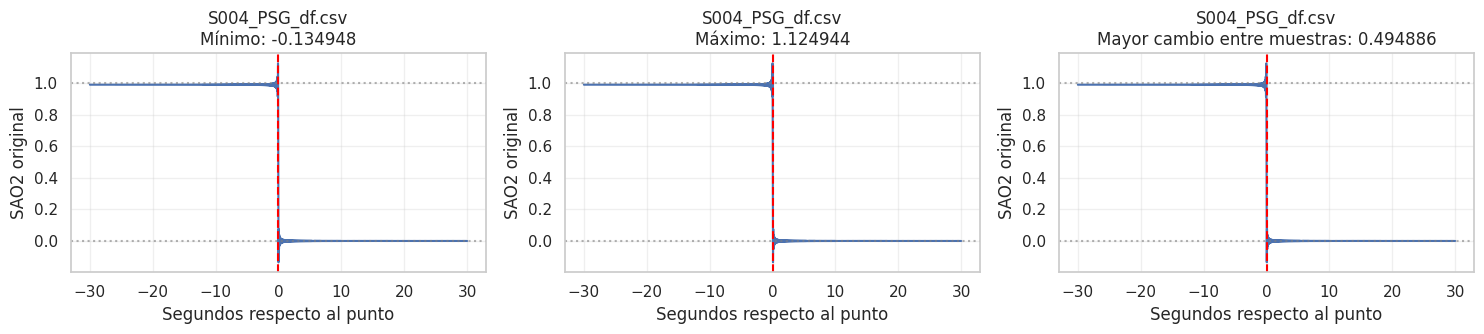


Inspeccionando SAO2: S006_PSG_df.csv


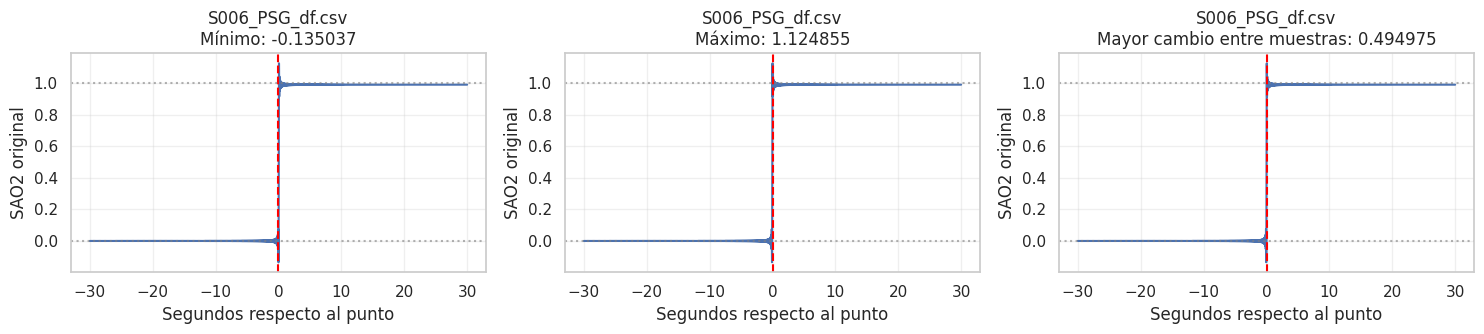


Inspeccionando SAO2: S027_PSG_df.csv


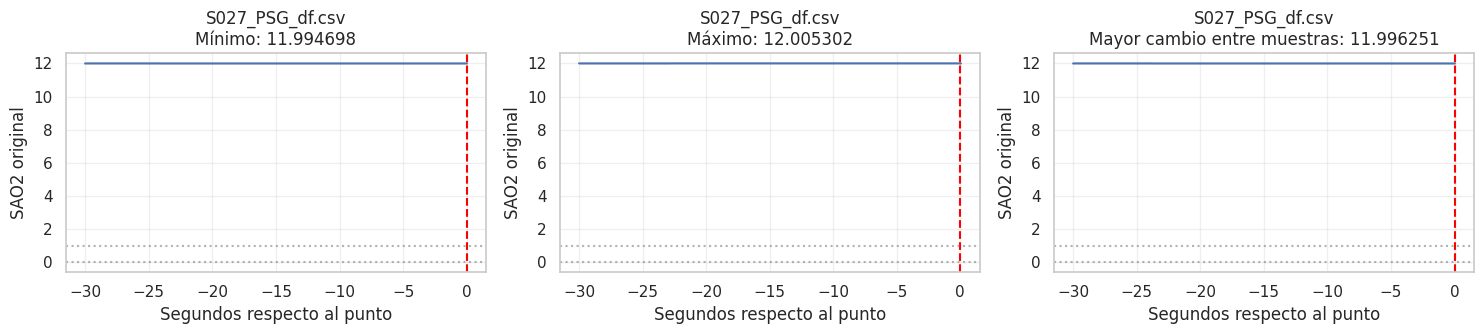


ESTADÍSTICAS DE LOS TRES REGISTROS


,count,mean,std,min,1%,50%,99%,max,archivo,negativos,mayores_1,ceros_exactos
0,2413100.0,0.893009,0.079369,-0.134948,0.740000,0.899768,0.980061,1.124944,S004_PSG_df.csv,1458,19,0
1,2403000.0,0.961867,0.094311,-0.135037,0.919763,0.969924,0.989707,1.124855,S006_PSG_df.csv,2470,36,0
2,2276900.0,12.000000,0.001338,11.994698,11.996332,12.000000,12.003668,12.005302,S027_PSG_df.csv,0,2276900,0



UBICACIÓN DE LOS PUNTOS INSPECCIONADOS


,archivo,motivo,fila_original,TIMESTAMP,SAO2,SAO2_anterior
0,S004_PSG_df.csv,Mínimo,238270,9222.70,-0.134948,-0.118288
1,S004_PSG_df.csv,Máximo,238262,9222.62,1.124944,1.069550
2,S004_PSG_df.csv,Mayor cambio entre muestras,238266,9222.66,0.494886,0.772511
3,S006_PSG_df.csv,Mínimo,2006222,27262.22,-0.135037,-0.079650
4,S006_PSG_df.csv,Máximo,2006230,27262.30,1.124855,1.108188
5,S006_PSG_df.csv,Mayor cambio entre muestras,2006226,27262.26,0.494975,0.217356
6,S027_PSG_df.csv,Mínimo,2276898,31078.98,11.994698,11.996251
7,S027_PSG_df.csv,Máximo,2276894,31078.94,12.005302,12.003749
8,S027_PSG_df.csv,Mayor cambio entre muestras,2276897,31078.97,11.996251,12.000000



No se modificaron valores. Los gráficos tienen escalas verticales independientes. Falta contrastar los casos con el procesamiento de origen.


In [19]:
# 2.6.2. Inspección de SAO2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

carpeta_revision = Path("/kaggle/working/auditoria")

# Utilizar la auditoría guardada; no recorrer nuevamente los 68 CSV.
auditoria_p = pd.read_csv(
    carpeta_revision / "auditoria_pacientes.csv"
)
auditoria_s = pd.read_csv(
    carpeta_revision / "auditoria_senales.csv"
)

rangos_sao2 = auditoria_s.loc[
    auditoria_s["señal"].eq("SAO2"),
    ["archivo", "minimo", "maximo"],
]

resumen_sao2 = auditoria_p[
    ["archivo", "filas", "ceros_sao2", "sao2_fuera_escala_0_1"]
].merge(rangos_sao2, on="archivo", how="left")

resumen_sao2["fuera_0_1_pct"] = (
    100 * resumen_sao2["sao2_fuera_escala_0_1"]
    / resumen_sao2["filas"]
)

print("RESUMEN GENERAL DE SAO2")
print(
    "Pacientes con muestras fuera de 0–1:",
    int(resumen_sao2["sao2_fuera_escala_0_1"].gt(0).sum()),
)
print(
    "Pacientes con ceros exactos:",
    int(resumen_sao2["ceros_sao2"].gt(0).sum()),
)

# Mostrar los rangos más alejados del intervalo supuesto.
print("\nDIEZ PACIENTES CON MAYOR PORCENTAJE FUERA DE 0–1")
display(
    resumen_sao2.sort_values(
        "fuera_0_1_pct", ascending=False
    ).head(10).round(5)
)

nombres_revision_sao2 = [
    "S004_PSG_df.csv",
    "S006_PSG_df.csv",
    "S027_PSG_df.csv",
]

estadisticas_sao2 = []
puntos_revision_sao2 = []

for nombre in nombres_revision_sao2:
    ruta = next(p for p in data_files if p.name == nombre)
    print(f"\nInspeccionando SAO2: {nombre}", flush=True)

    # Solo dos columnas; un paciente por vez.
    datos = pd.read_csv(
        ruta,
        usecols=["TIMESTAMP", "SAO2"],
    )

    valores = pd.to_numeric(datos["SAO2"], errors="coerce")
    tiempos = pd.to_numeric(datos["TIMESTAMP"], errors="coerce")
    finitos = valores.where(np.isfinite(valores))

    if finitos.notna().sum() == 0:
        print("No hay valores finitos para inspeccionar.")
        continue

    estadisticas = finitos.describe(
        percentiles=[0.01, 0.50, 0.99]
    ).to_dict()
    estadisticas["archivo"] = nombre
    estadisticas["negativos"] = int(finitos.lt(0).sum())
    estadisticas["mayores_1"] = int(finitos.gt(1).sum())
    estadisticas["ceros_exactos"] = int(finitos.eq(0).sum())
    estadisticas_sao2.append(estadisticas)

    # Diferencia absoluta entre muestras consecutivas.
    diferencias = finitos.diff().abs()

    posiciones = {
        "Mínimo": int(finitos.idxmin()),
        "Máximo": int(finitos.idxmax()),
    }

    if diferencias.notna().any():
        posiciones["Mayor cambio entre muestras"] = int(
            diferencias.idxmax()
        )

    fig, axes = plt.subplots(
        1, len(posiciones),
        figsize=(5 * len(posiciones), 3.5),
        squeeze=False,
    )

    for ax, (motivo, posicion) in zip(
        axes[0], posiciones.items()
    ):
        inicio = max(0, posicion - 3000)
        fin = min(len(datos), posicion + 3001)

        ax.plot(
            tiempos.iloc[inicio:fin] - tiempos.iloc[posicion],
            valores.iloc[inicio:fin],
        )
        ax.axvline(0, color="red", linestyle="--")

        # Referencias de escala; no son reglas de limpieza.
        ax.axhline(0, color="gray", linestyle=":", alpha=0.6)
        ax.axhline(1, color="gray", linestyle=":", alpha=0.6)

        ax.set_title(
            f"{nombre}\n{motivo}: {valores.iloc[posicion]:.6f}"
        )
        ax.set_xlabel("Segundos respecto al punto")
        ax.set_ylabel("SAO2 original")
        ax.grid(alpha=0.3)

        puntos_revision_sao2.append({
            "archivo": nombre,
            "motivo": motivo,
            "fila_original": posicion,
            "TIMESTAMP": tiempos.iloc[posicion],
            "SAO2": valores.iloc[posicion],
            "SAO2_anterior": (
                valores.iloc[posicion - 1]
                if posicion > 0 else np.nan
            ),
        })

    plt.tight_layout()
    plt.show()

    del datos, valores, tiempos, finitos, diferencias

estadisticas_sao2 = pd.DataFrame(estadisticas_sao2)
puntos_revision_sao2 = pd.DataFrame(puntos_revision_sao2)

print("\nESTADÍSTICAS DE LOS TRES REGISTROS")
display(estadisticas_sao2.round(6))

print("\nUBICACIÓN DE LOS PUNTOS INSPECCIONADOS")
display(puntos_revision_sao2)

estadisticas_sao2.to_csv(
    carpeta_revision / "revision_estadisticas_sao2.csv",
    index=False,
)
puntos_revision_sao2.to_csv(
    carpeta_revision / "revision_puntos_sao2.csv",
    index=False,
)

print(
    "\nNo se modificaron valores. "
    "Los gráficos tienen escalas verticales independientes. "
    "Falta contrastar los casos con el procesamiento de origen."
)

### 2.6.3. Revisión de señales constantes

Se identifican señales constantes durante todo el registro y tramos
prolongados sin cambios, utilizando los resultados de la auditoría general.

Se priorizan S097 y los pacientes con IBI constante. Una señal
numérica y sin nulos puede igualmente carecer de variación útil.

Los tramos constantes no se consideran errores automáticamente:
pueden relacionarse con el registro, el relleno o el procesamiento.
No se modifican ni eliminan señales en esta revisión.

In [20]:
# 2.6.3. Revisión de señales constantes
import pandas as pd
from pathlib import Path

carpeta_revision = Path("/kaggle/working/auditoria")
auditoria_constantes = pd.read_csv(
    carpeta_revision / "auditoria_senales.csv"
)

columnas_detalle = [
    "archivo",
    "señal",
    "filas",
    "minimo",
    "maximo",
    "mayor_tramo_constante_muestras",
    "inicio_tramo_constante_fila",
    "duracion_constante_segundos_100hz",
]

# Porcentaje del registro ocupado por su mayor tramo constante.
auditoria_constantes["mayor_tramo_constante_pct"] = (
    100
    * auditoria_constantes["mayor_tramo_constante_muestras"]
    / auditoria_constantes["filas"]
)

# Constancia en todas las muestras del registro.
constantes_completas = auditoria_constantes.loc[
    auditoria_constantes["mayor_tramo_constante_muestras"].eq(
        auditoria_constantes["filas"]
    )
    & auditoria_constantes["filas"].gt(0)
].copy()

print("SEÑALES CONSTANTES DURANTE TODO EL REGISTRO")
display(
    constantes_completas[
        columnas_detalle + ["mayor_tramo_constante_pct"]
    ].sort_values(["archivo", "señal"])
)

print("\nCANTIDAD DE SEÑALES COMPLETAMENTE CONSTANTES POR PACIENTE")
display(
    constantes_completas.groupby("archivo")
    .size()
    .rename("señales_constantes")
    .reset_index()
)

print("\nDETALLE DE S097")
display(
    auditoria_constantes.loc[
        auditoria_constantes["archivo"].eq("S097_PSG_df.csv"),
        columnas_detalle + ["mayor_tramo_constante_pct"],
    ].sort_values("señal")
)

print("\nIBI: DIEZ MAYORES TRAMOS CONSTANTES")
display(
    auditoria_constantes.loc[
        auditoria_constantes["señal"].eq("IBI"),
        columnas_detalle + ["mayor_tramo_constante_pct"],
    ]
    .sort_values("mayor_tramo_constante_pct", ascending=False)
    .head(10)
)

# Umbral exploratorio, no una regla de eliminación.
tramos_prolongados = auditoria_constantes.loc[
    auditoria_constantes[
        "duracion_constante_segundos_100hz"
    ].ge(30)
].copy()

print("\nTRAMOS CONSTANTES DE AL MENOS 30 SEGUNDOS")
display(
    tramos_prolongados.groupby("señal")
    .agg(
        pacientes=("archivo", "nunique"),
        mayor_duracion_segundos=(
            "duracion_constante_segundos_100hz", "max"
        ),
    )
    .reset_index()
    .sort_values("pacientes", ascending=False)
)

constantes_completas.to_csv(
    carpeta_revision / "revision_constantes_completas.csv",
    index=False,
)

print(
    "\nNo se modificaron señales. "
    "Una señal completamente constante tendrá desviación estándar "
    "cero en sus epochs, pero eso no explica la causa. "
    "La duración supone continuidad a 100 Hz, "
    "comprobada en la auditoría general."
)

SEÑALES CONSTANTES DURANTE TODO EL REGISTRO


,archivo,señal,filas,minimo,maximo,mayor_tramo_constante_muestras,inicio_tramo_constante_fila,duracion_constante_segundos_100hz,mayor_tramo_constante_pct
649,S026_PSG_df.csv,IBI,2186900,7.500000e-01,7.500000e-01,2186900,0.0,21868.99,100.0
753,S030_PSG_df.csv,IBI,2193000,9.843750e-01,9.843750e-01,2193000,0.0,21929.99,100.0
909,S036_PSG_df.csv,IBI,2715700,5.625000e-01,5.625000e-01,2715700,0.0,27156.99,100.0
1143,S046_PSG_df.csv,IBI,2150300,3.906250e-01,3.906250e-01,2150300,0.0,21502.99,100.0
1732,S097_PSG_df.csv,ABDOMEN,2126000,4.882887e-08,4.882887e-08,2126000,0.0,21259.99,100.0
1716,S097_PSG_df.csv,C4-M1,2126000,4.882887e-08,4.882887e-08,2126000,0.0,21259.99,100.0
1722,S097_PSG_df.csv,CHIN,2126000,4.882887e-08,4.882887e-08,2126000,0.0,21259.99,100.0
1721,S097_PSG_df.csv,CZ - T4,2126000,4.882887e-08,4.882887e-08,2126000,0.0,21259.99,100.0
1723,S097_PSG_df.csv,E1,2126000,4.882887e-08,4.882887e-08,2126000,0.0,21259.99,100.0
1724,S097_PSG_df.csv,E2,2126000,4.882887e-08,4.882887e-08,2126000,0.0,21259.99,100.0



CANTIDAD DE SEÑALES COMPLETAMENTE CONSTANTES POR PACIENTE


,archivo,señales_constantes
0,S026_PSG_df.csv,1
1,S030_PSG_df.csv,1
2,S036_PSG_df.csv,1
3,S046_PSG_df.csv,1
4,S097_PSG_df.csv,18



DETALLE DE S097


...


IBI: DIEZ MAYORES TRAMOS CONSTANTES


,archivo,señal,filas,minimo,maximo,mayor_tramo_constante_muestras,inicio_tramo_constante_fila,duracion_constante_segundos_100hz,mayor_tramo_constante_pct
1143,S046_PSG_df.csv,IBI,2150300,0.390625,0.390625,2150300,0.0,21502.99,100.000000
649,S026_PSG_df.csv,IBI,2186900,0.750000,0.750000,2186900,0.0,21868.99,100.000000
909,S036_PSG_df.csv,IBI,2715700,0.562500,0.562500,2715700,0.0,27156.99,100.000000
753,S030_PSG_df.csv,IBI,2193000,0.984375,0.984375,2193000,0.0,21929.99,100.000000
1741,S097_PSG_df.csv,IBI,2126000,1.031250,1.031250,2126000,0.0,21259.99,100.000000
415,S017_PSG_df.csv,IBI,2311500,1.031250,1.546875,2272963,38537.0,22729.62,98.332814
1455,S058_PSG_df.csv,IBI,2298000,0.375000,1.437500,1902444,395556.0,19024.43,82.786945
1377,S055_PSG_df.csv,IBI,2307300,0.578125,0.937500,1873404,433896.0,18734.03,81.194643
1091,S044_PSG_df.csv,IBI,2229000,0.390625,2.000000,1799225,429775.0,17992.24,80.718932
1533,S067_PSG_df.csv,IBI,2465200,0.734375,1.968750,1620193,845007.0,16201.92,65.722578



TRAMOS CONSTANTES DE AL MENOS 30 SEGUNDOS


,señal,pacientes,mayor_duracion_segundos
1,ACC_X,68,10045.04
2,ACC_Y,68,1946.12
15,IBI,68,27156.99
3,ACC_Z,67,1163.52
4,BVP,65,74.86
23,TEMP,65,75.84
14,HR,65,103.77
11,EDA,65,1479.75
0,ABDOMEN,1,21259.99
8,E1,1,21259.99



No se modificaron señales. Una señal completamente constante tendrá desviación estándar cero en sus epochs, pero eso no explica la causa. La duración supone continuidad a 100 Hz, comprobada en la auditoría general.


### 2.6.4. Revisión de diferencias en EDA

Se comparan los rangos de EDA de todos los pacientes a partir de
la auditoría. Después se inspeccionan S002, S004 y S057:
S002 como referencia inicial y los otros dos por sus máximos elevados.

Se visualizan el registro completo, el entorno del máximo y el
mayor cambio entre muestras consecutivas. También se muestran
los ejes del acelerómetro alrededor de ese cambio para aportar contexto.

EDA está documentada en microsiemens (µS). Las diferencias entre
pacientes y los cambios coincidentes con movimiento no confirman
por sí solos un artefacto. No se recortan ni normalizan valores.

DIEZ MAYORES MÁXIMOS DE EDA


,archivo,minimo,maximo,nulos,infinitos
1427,S057_PSG_df.csv,0.031015,57.666389,0,0
75,S004_PSG_df.csv,0.102755,53.174881,0,0
673,S027_PSG_df.csv,2.368708,34.935596,0,0
1063,S043_PSG_df.csv,1.656697,21.967810,0,0
699,S028_PSG_df.csv,0.648455,17.295322,0,0
1297,S052_PSG_df.csv,0.000000,14.436932,0,0
543,S022_PSG_df.csv,0.543424,11.731063,0,0
465,S019_PSG_df.csv,0.000000,10.431508,0,0
881,S035_PSG_df.csv,0.042535,10.409482,0,0
1115,S045_PSG_df.csv,1.641328,9.707808,0,0



Inspeccionando EDA: S002_PSG_df.csv


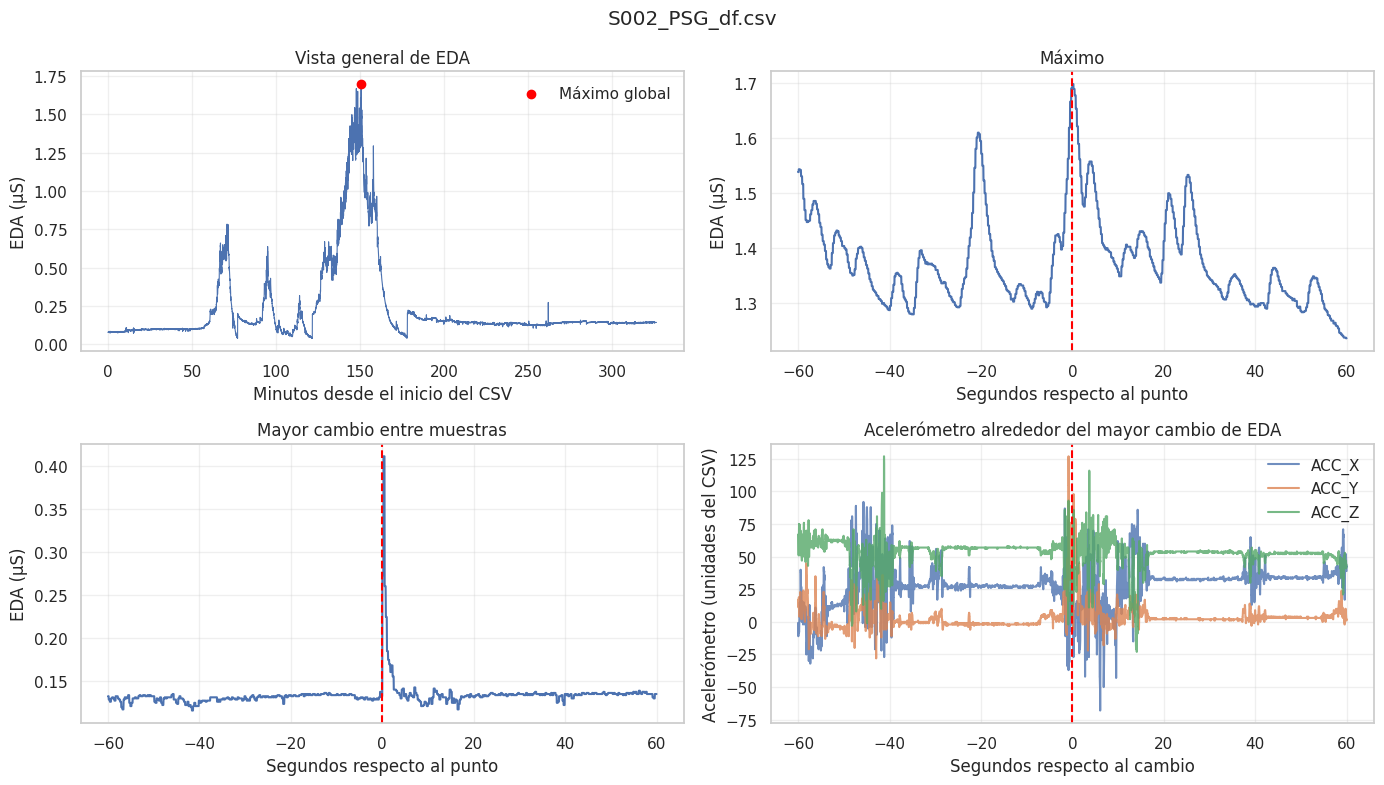


Inspeccionando EDA: S004_PSG_df.csv


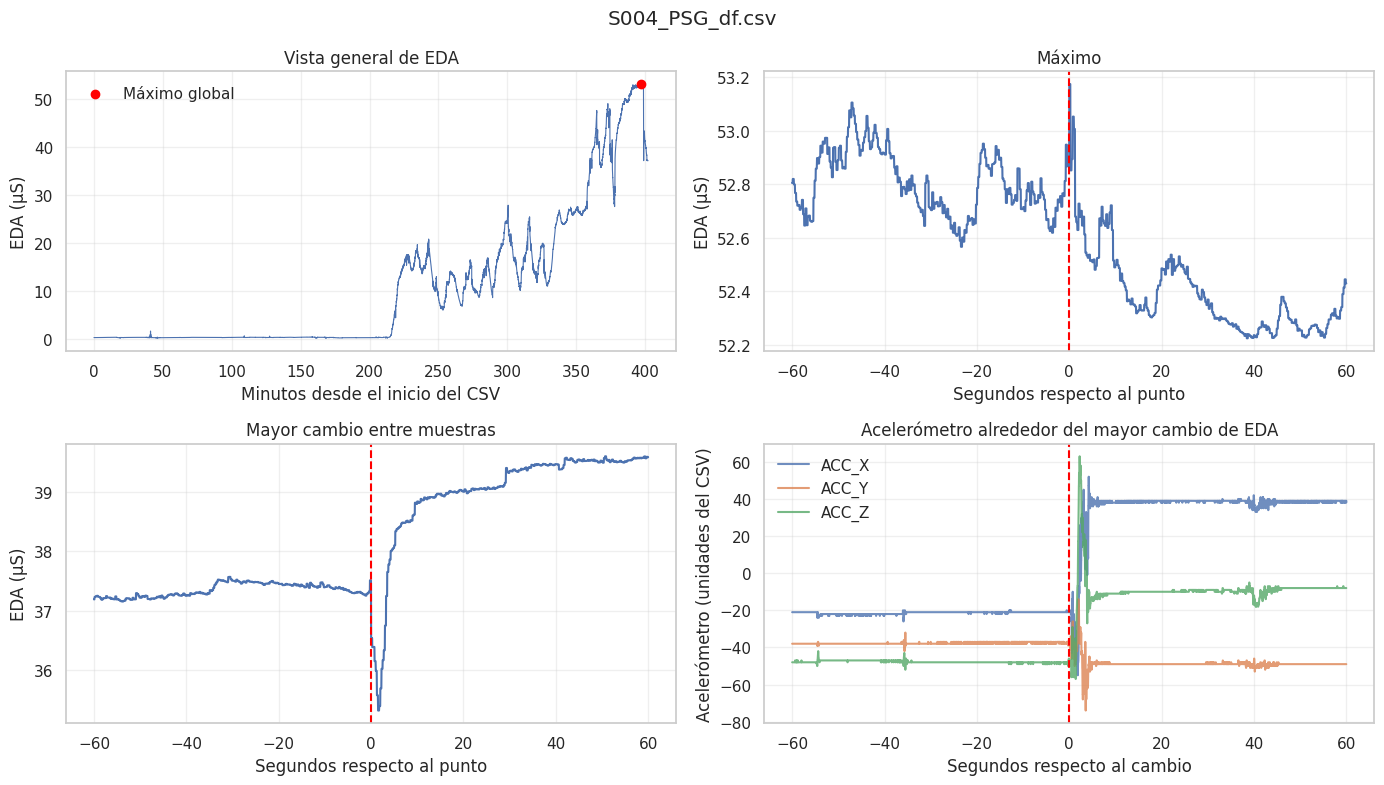


Inspeccionando EDA: S057_PSG_df.csv


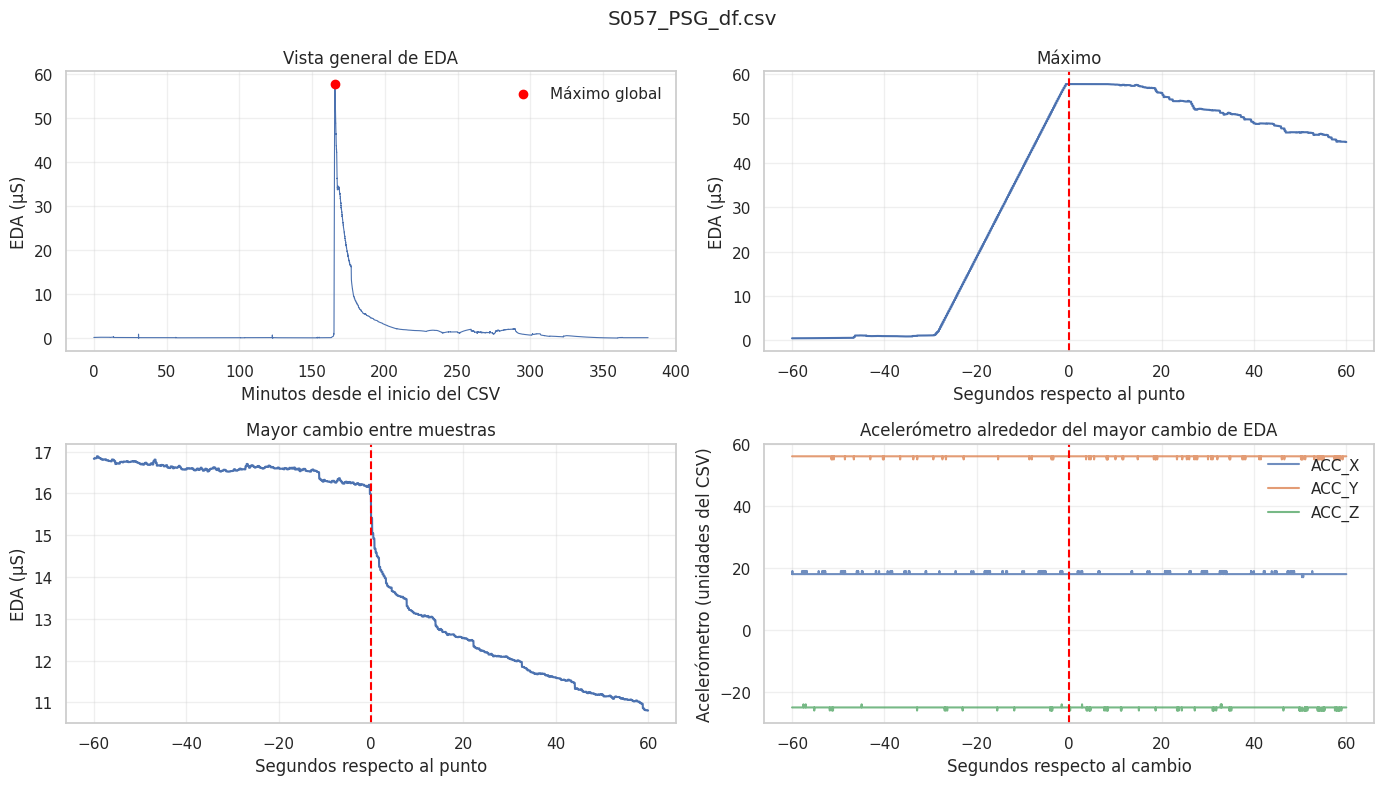


ESTADÍSTICAS DE EDA POR PACIENTE


,count,mean,std,min,1%,25%,50%,75%,99%,max,archivo,valores_negativos,mayor_cambio_absoluto
0,1958400.0,0.231192,0.267470,0.036129,0.051498,0.109197,0.139606,0.167784,1.360635,1.698764,S002_PSG_df.csv,0,0.130614
1,2413100.0,10.635652,14.412380,0.102755,0.207805,0.280828,0.324385,16.530336,52.520241,53.174881,S004_PSG_df.csv,0,0.912041
2,2286000.0,1.829836,5.321679,0.031015,0.110448,0.167834,0.245986,1.551940,32.728745,57.666389,S057_PSG_df.csv,0,0.558282



UBICACIÓN DE LOS PUNTOS INSPECCIONADOS


,archivo,motivo,fila_original,TIMESTAMP,EDA,EDA_anterior,cambio_entre_muestras
0,S002_PSG_df.csv,Máximo,903539,20915.39,1.698764,1.698090,0.000674
1,S002_PSG_df.csv,Mayor cambio entre muestras,1571881,27598.81,0.272808,0.142194,0.130614
2,S004_PSG_df.csv,Máximo,2381748,30657.48,53.174881,52.904557,0.270324
3,S004_PSG_df.csv,Mayor cambio entre muestras,2167659,28516.59,36.541969,37.454010,-0.912041
4,S057_PSG_df.csv,Máximo,993377,19413.77,57.666389,57.664639,0.001750
5,S057_PSG_df.csv,Mayor cambio entre muestras,1061502,20095.02,15.413518,15.971800,-0.558282



No se modificaron valores. La vista general puede ocultar eventos breves por su muestreo visual; los gráficos locales utilizan todas las muestras. Los valores elevados o el movimiento coincidente no confirman por sí solos un error.


In [21]:
# 2.6.4. Inspección de EDA y contexto de movimiento
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

carpeta_revision = Path("/kaggle/working/auditoria")

auditoria_eda = pd.read_csv(
    carpeta_revision / "auditoria_senales.csv"
)

rangos_eda = auditoria_eda.loc[
    auditoria_eda["señal"].eq("EDA"),
    ["archivo", "minimo", "maximo", "nulos", "infinitos"],
].sort_values("maximo", ascending=False)

print("DIEZ MAYORES MÁXIMOS DE EDA")
display(rangos_eda.head(10))

nombres_revision_eda = [
    "S002_PSG_df.csv",
    "S004_PSG_df.csv",
    "S057_PSG_df.csv",
]

columnas_leer = [
    "TIMESTAMP", "EDA", "ACC_X", "ACC_Y", "ACC_Z"
]
estadisticas_eda = []
puntos_revision_eda = []

for nombre in nombres_revision_eda:
    ruta = next(p for p in data_files if p.name == nombre)
    print(f"\nInspeccionando EDA: {nombre}", flush=True)

    if ruta == sample_file:
        datos = df_sample_eda[columnas_leer].copy()
    else:
        datos = pd.read_csv(ruta, usecols=columnas_leer)

    datos = datos.reset_index(drop=True)

    valores = pd.to_numeric(datos["EDA"], errors="coerce")
    tiempos = pd.to_numeric(
        datos["TIMESTAMP"], errors="coerce"
    )
    finitos = valores.where(np.isfinite(valores))

    if finitos.notna().sum() == 0:
        print("No hay valores finitos para inspeccionar.")
        del datos
        continue

    diferencias = finitos.diff()
    diferencias_absolutas = diferencias.abs()

    if not diferencias_absolutas.notna().any():
        print("No hay pares válidos para calcular cambios.")
        del datos
        continue

    posicion_maximo = int(finitos.idxmax())
    posicion_cambio = int(diferencias_absolutas.idxmax())

    resumen = finitos.describe(
        percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
    ).to_dict()
    resumen["archivo"] = nombre
    resumen["valores_negativos"] = int(finitos.lt(0).sum())
    resumen["mayor_cambio_absoluto"] = float(
        diferencias_absolutas.iloc[posicion_cambio]
    )
    estadisticas_eda.append(resumen)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    # 1. Vista general: tomar una muestra por segundo para dibujar.
    # Solo reduce los puntos del gráfico; no cambia los datos analizados.
    posiciones_vista = np.arange(0, len(datos), 100)

    axes[0, 0].plot(
        (tiempos.iloc[posiciones_vista] - tiempos.iloc[0]) / 60,
        valores.iloc[posiciones_vista],
        linewidth=0.8,
    )
    axes[0, 0].scatter(
        (tiempos.iloc[posicion_maximo] - tiempos.iloc[0]) / 60,
        valores.iloc[posicion_maximo],
        color="red",
        label="Máximo global",
        zorder=5,
    )
    axes[0, 0].set_title("Vista general de EDA")
    axes[0, 0].set_xlabel("Minutos desde el inicio del CSV")
    axes[0, 0].set_ylabel("EDA (µS)")
    axes[0, 0].legend()

    # 2 y 3. Hasta 60 segundos alrededor del máximo y mayor cambio.
    for ax, motivo, posicion in [
        (axes[0, 1], "Máximo", posicion_maximo),
        (axes[1, 0], "Mayor cambio entre muestras", posicion_cambio),
    ]:
        inicio = max(0, posicion - 6000)
        fin = min(len(datos), posicion + 6001)

        ax.plot(
            tiempos.iloc[inicio:fin] - tiempos.iloc[posicion],
            valores.iloc[inicio:fin],
        )
        ax.axvline(0, color="red", linestyle="--")
        ax.set_title(motivo)
        ax.set_xlabel("Segundos respecto al punto")
        ax.set_ylabel("EDA (µS)")

        puntos_revision_eda.append({
            "archivo": nombre,
            "motivo": motivo,
            "fila_original": posicion,
            "TIMESTAMP": tiempos.iloc[posicion],
            "EDA": valores.iloc[posicion],
            "EDA_anterior": (
                valores.iloc[posicion - 1]
                if posicion > 0 else np.nan
            ),
            "cambio_entre_muestras": diferencias.iloc[posicion],
        })

    # 4. Acelerómetro en el MISMO intervalo del mayor cambio de EDA.
    inicio = max(0, posicion_cambio - 6000)
    fin = min(len(datos), posicion_cambio + 6001)
    tiempo_relativo = (
        tiempos.iloc[inicio:fin] - tiempos.iloc[posicion_cambio]
    )

    for eje in ["ACC_X", "ACC_Y", "ACC_Z"]:
        axes[1, 1].plot(
            tiempo_relativo,
            pd.to_numeric(
                datos[eje].iloc[inicio:fin], errors="coerce"
            ),
            label=eje,
            alpha=0.8,
        )

    axes[1, 1].axvline(0, color="red", linestyle="--")
    axes[1, 1].set_title(
        "Acelerómetro alrededor del mayor cambio de EDA"
    )
    axes[1, 1].set_xlabel("Segundos respecto al cambio")
    axes[1, 1].set_ylabel("Acelerómetro (unidades del CSV)")
    axes[1, 1].legend()

    for ax in axes.flat:
        ax.grid(alpha=0.3)

    fig.suptitle(nombre)
    plt.tight_layout()
    plt.show()

    del datos, valores, tiempos, finitos
    del diferencias, diferencias_absolutas

estadisticas_eda = pd.DataFrame(estadisticas_eda)
puntos_revision_eda = pd.DataFrame(puntos_revision_eda)

print("\nESTADÍSTICAS DE EDA POR PACIENTE")
display(estadisticas_eda.round(6))

print("\nUBICACIÓN DE LOS PUNTOS INSPECCIONADOS")
display(puntos_revision_eda)

estadisticas_eda.to_csv(
    carpeta_revision / "revision_estadisticas_eda.csv",
    index=False,
)
puntos_revision_eda.to_csv(
    carpeta_revision / "revision_puntos_eda.csv",
    index=False,
)

print(
    "\nNo se modificaron valores. "
    "La vista general puede ocultar eventos breves por su muestreo "
    "visual; los gráficos locales utilizan todas las muestras. "
    "Los valores elevados o el movimiento coincidente no confirman "
    "por sí solos un error."
)

# 3. Preparación y evaluación del dataset de epochs
Preparamos una tabla con una fila por paciente y epoch completo de 30 segundos.

- Se verifica continuidad a 100 Hz y se infiere la alineación a partir de los cambios entre etapas válidas.
- Se definen los epochs antes de filtrar filas. Se contabilizan los fragmentos incompletos.
- Se conservan las señales originales, incluidos sus posibles nulos. El recorte por percentiles y la interpolación automática están desactivados.
- Las anotaciones respiratorias no se utilizan como predictores; sí se conservan las señales fisiológicas respiratorias.
- Se calculan media, desviación estándar, mediana y cobertura de cada señal por epoch.

La documentación de DREAMT indica que la preparación (`P`) aparece como `W` en los archivos de 100 Hz. Por eso, `W` por sí solo no permite distinguir preparación de vigilia real.

Fuente del dataset: [DREAMT 2.2.0](https://physionet.org/content/dreamt/2.2.0/).

In [ ]:
# Funciones Modulares de Limpieza a 100 Hz

def clean_sleep_stages(df):
    """Conserva filas, orden y etiquetas antes del agrupamiento temporal."""
    if "Sleep_Stage" not in df.columns:
        raise ValueError("Falta la columna Sleep_Stage.")

    return df.copy()


def clean_sao2(df):
    """
    Conserva SAO2 original, incluidos sus posibles faltantes.

    No aplica umbrales ni interpolación automática mientras
    esas reglas no estén justificadas.
    """
    return df

def clean_outliers_wearable_psg(df):
    """
    Conserva las señales originales.

    El recorte por percentiles y el relleno de nulos quedan
    desactivados hasta justificar sus reglas con evidencia.
    """
    return df

def run_etl_pipeline(df):
    """Prepara señales para predecir la etapa de sueño."""
    df = clean_sleep_stages(df)
    df = clean_sao2(df)
    df = clean_outliers_wearable_psg(df)
    return df

## 3.1. Generación de la primera versión del dataset de epochs

Se procesan los registros completos, con ventanas de 30 segundos
alineadas por paciente.

S027 y S048 quedan pendientes por su alineación inconsistente.
S097 queda pendiente por sus señales PSG constantes.

SAO2 e IBI se excluyen provisionalmente de las características.
Las demás señales se conservan sin recortes ni imputación automática.

Se mantienen únicamente epochs completos con una misma etiqueta
válida en las 3000 muestras. Las exclusiones se registran y los
resultados se guardan por paciente y en una tabla conjunta.

In [22]:
# 3.1. Primera versión del dataset de epochs
import gc
import numpy as np
import pandas as pd
from pathlib import Path

carpeta_etl = Path("/kaggle/working/etl_v1")
carpeta_etl.mkdir(parents=True, exist_ok=True)

# Exclusiones provisionales justificadas por la auditoría.
motivos_exclusion = {
    "S027_PSG_df.csv": "Alineación inconsistente",
    "S048_PSG_df.csv": "Alineación inconsistente",
    "S097_PSG_df.csv": "Señales PSG constantes durante todo el registro",
}

exclusiones_pacientes = pd.DataFrame([
    {"archivo": nombre, "motivo": motivo}
    for nombre, motivo in motivos_exclusion.items()
])

exclusiones_pacientes.to_csv(
    carpeta_etl / "pacientes_pendientes.csv",
    index=False,
)

archivos_procesar = [
    p for p in data_files if p.name not in motivos_exclusion
]

if len(data_files) != 68 or len(archivos_procesar) != 65:
    raise ValueError(
        "Se esperaban 68 archivos originales y 65 para esta versión. "
        "Revisar data_files antes de continuar."
    )

if len({p.name for p in data_files}) != len(data_files):
    raise ValueError("Hay nombres de archivos duplicados.")

window_size = 3000
etapas_validas = ["W", "N1", "N2", "N3", "R"]

wearable_cols = [
    "BVP", "HR", "EDA", "TEMP",
    "ACC_X", "ACC_Y", "ACC_Z",
]

psg_cols = [
    "C4-M1", "F4-M1", "O2-M1", "Fp1-O2",
    "T3 - CZ", "CZ - T4", "CHIN", "E1", "E2",
    "ECG", "LAT", "RAT", "SNORE", "PTAF",
    "FLOW", "THORAX", "ABDOMEN",
]

senales_modelo = wearable_cols + psg_cols
columnas_leer = ["TIMESTAMP", "Sleep_Stage"] + senales_modelo

resultados_epochs = []
resumen_temporal = []
exclusiones_epochs = []

print("Pacientes a procesar:", len(archivos_procesar))
print("Señales incluidas:", len(senales_modelo))

for numero, file_path in enumerate(archivos_procesar, start=1):
    patient_id = extract_patient_id(file_path)

    print(
        f"[{numero}/{len(archivos_procesar)}] {file_path.name}",
        flush=True,
    )

    # Leer solo las columnas utilizadas en esta versión.
    df_raw = pd.read_csv(
        file_path,
        usecols=columnas_leer,
        low_memory=False,
    )

    # Definir ventanas sobre posiciones originales.
    epoch_ids, completos, diagnostico = definir_epochs(df_raw)
    timestamp_inicio_csv = df_raw["TIMESTAMP"].iloc[0]

    df_raw["epoch"] = epoch_ids
    df_raw = df_raw.loc[completos].copy()

    grupos = df_raw.groupby("epoch", sort=True)

    # Agregación directa: no ejecutar una función Python por epoch.
    estadisticas = grupos[senales_modelo].agg(
        ["mean", "std", "median", "count"]
    )

    estadisticas.columns = [
        f"{senal}_{'n_valid' if operacion == 'count' else operacion}"
        for senal, operacion in estadisticas.columns
    ]

    for senal in senales_modelo:
        estadisticas[f"{senal}_missing_frac"] = (
            1 - estadisticas[f"{senal}_n_valid"] / window_size
        )

    # Contar solamente etiquetas válidas, conservando las posiciones.
    etiquetas_validas = df_raw["Sleep_Stage"].where(
        df_raw["Sleep_Stage"].isin(etapas_validas)
    )

    conteos_etapas = (
        etiquetas_validas.groupby(df_raw["epoch"])
        .value_counts()
        .unstack(fill_value=0)
        .reindex(
            index=estadisticas.index,
            columns=etapas_validas,
            fill_value=0,
        )
        .fillna(0)
    )

    mayor_conteo = conteos_etapas.max(axis=1)

    # Si no hay etiquetas válidas, el objetivo permanece faltante.
    objetivo = conteos_etapas.idxmax(axis=1).where(
        mayor_conteo.gt(0)
    )
    pureza = mayor_conteo / window_size

    estadisticas["TIMESTAMP"] = grupos["TIMESTAMP"].first()
    estadisticas["tiempo_relativo_segundos"] = (
        estadisticas["TIMESTAMP"] - timestamp_inicio_csv
    )
    estadisticas["Sleep_Stage"] = objetivo
    estadisticas["porcentaje_pureza"] = pureza

    # Primera versión: conservar únicamente epochs completamente puros.
    conservar = mayor_conteo.eq(window_size)

    descartados = pd.DataFrame({
        "epoch": estadisticas.index,
        "porcentaje_pureza": pureza.to_numpy(),
        "muestras_con_etiqueta_valida":
            conteos_etapas.sum(axis=1).to_numpy(),
    }).loc[~conservar.to_numpy()].copy()

    if not descartados.empty:
        descartados.insert(0, "archivo", file_path.name)
        descartados.insert(0, "patient_id", patient_id)
        descartados["motivo"] = (
            "No contiene 3000 muestras de una misma etapa válida"
        )
        exclusiones_epochs.append(descartados)

    df_epochs = estadisticas.loc[conservar].reset_index()
    df_epochs.insert(0, "patient_id", patient_id)

    # Optimizar memoria de características, conservando tiempos en float64.
    columnas_estadisticas = [
        c for c in df_epochs.columns
        if c.endswith(("_mean", "_std", "_median", "_missing_frac"))
    ]
    df_epochs[columnas_estadisticas] = (
        df_epochs[columnas_estadisticas].astype("float32")
    )

    diagnostico.update({
        "patient_id": patient_id,
        "archivo": file_path.name,
        "alcance": "Registro completo",
        "epochs_descartados_por_pureza": int((~conservar).sum()),
        "epochs_conservados": len(df_epochs),
    })

    resultados_epochs.append(df_epochs)
    resumen_temporal.append(diagnostico)

    # Guardar avance; no implica reanudación automática.
    df_epochs.to_csv(
        carpeta_etl / f"{file_path.stem}_epochs.csv",
        index=False,
    )
    pd.DataFrame(resumen_temporal).to_csv(
        carpeta_etl / "auditoria_epochs.csv",
        index=False,
    )

    print(
        f"  Conservados: {len(df_epochs)} | "
        f"Descartados: {int((~conservar).sum())}",
        flush=True,
    )

    del df_raw, grupos, estadisticas, conteos_etapas
    del etiquetas_validas, objetivo, pureza, mayor_conteo
    gc.collect()

# Consolidar resultados.
df_epochs_all = pd.concat(resultados_epochs, ignore_index=True)
auditoria_epochs = pd.DataFrame(resumen_temporal)

if exclusiones_epochs:
    epochs_descartados = pd.concat(
        exclusiones_epochs, ignore_index=True
    )
else:
    epochs_descartados = pd.DataFrame(columns=[
        "patient_id", "archivo", "epoch", "porcentaje_pureza",
        "muestras_con_etiqueta_valida", "motivo",
    ])

# Control de clave de la tabla objetivo.
if df_epochs_all.duplicated(["patient_id", "epoch"]).any():
    raise ValueError("Hay claves patient_id/epoch duplicadas.")

df_epochs_all.to_csv(
    carpeta_etl / "dataset_epochs_v1.csv", index=False
)
epochs_descartados.to_csv(
    carpeta_etl / "epochs_descartados.csv", index=False
)

print("\nETL FINALIZADO")
print("Pacientes con epochs conservados:",
      df_epochs_all["patient_id"].nunique())
print("Dimensiones:", df_epochs_all.shape)
print("Epochs descartados:", len(epochs_descartados))

print("\nEPOCHS POR ETAPA")
print(df_epochs_all["Sleep_Stage"].value_counts().to_string())

print("\nNULOS EN EL RESULTADO")
nulos = df_epochs_all.isna().sum()
nulos = nulos[nulos.gt(0)]
print(nulos.to_string() if not nulos.empty else "Sin nulos.")

print("\nResultados guardados en:", carpeta_etl)

Pacientes a procesar: 65
Señales incluidas: 24
[1/65] S002_PSG_df.csv
  Conservados: 652 | Descartados: 0
[2/65] S003_PSG_df.csv
  Conservados: 773 | Descartados: 0
[3/65] S004_PSG_df.csv
  Conservados: 804 | Descartados: 0
[4/65] S005_PSG_df.csv
  Conservados: 730 | Descartados: 0
[5/65] S006_PSG_df.csv
  Conservados: 801 | Descartados: 0
[6/65] S007_PSG_df.csv
  Conservados: 797 | Descartados: 0
[7/65] S008_PSG_df.csv
  Conservados: 743 | Descartados: 0
[8/65] S009_PSG_df.csv
  Conservados: 766 | Descartados: 0
[9/65] S010_PSG_df.csv
  Conservados: 795 | Descartados: 0
[10/65] S011_PSG_df.csv
  Conservados: 807 | Descartados: 0
[11/65] S012_PSG_df.csv
  Conservados: 843 | Descartados: 0
[12/65] S013_PSG_df.csv
  Conservados: 784 | Descartados: 0
[13/65] S014_PSG_df.csv
  Conservados: 722 | Descartados: 0
[14/65] S015_PSG_df.csv
  Conservados: 938 | Descartados: 0
[15/65] S016_PSG_df.csv
  Conservados: 750 | Descartados: 0
[16/65] S017_PSG_df.csv
  Conservados: 770 | Descartados: 0
[1

### 3.2. Resumen Post-ETL y Consolidación

In [ ]:
# Mostrar dimensiones del resultado actual
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_epochs_all' in globals() and not df_epochs_all.empty:
    print("--- Resumen del Resultado Actual del ETL ---")
    num_cols = df_epochs_all.shape[1]
    print(f"Dimensiones de df_epochs_all: {df_epochs_all.shape} (Filas/Epochs x {num_cols} Columnas/Features)")
    
    # Memoria consumida (en MB)
    mem_mb = df_epochs_all.memory_usage(deep=True).sum() / (1024**2)
    print(f"Memoria consumida en RAM: {mem_mb:.2f} MB")
    
    # Verificación de nulos
    total_nulls = df_epochs_all.isnull().sum().sum()
    print(f"Total de valores nulos globales post-ETL: {total_nulls}\n")
    
    print('Pacientes incluidos:', df_epochs_all['patient_id'].nunique())
    if 'auditoria_epochs' in globals():
        display(auditoria_epochs)

    print("--- Diccionario de Datos ---")
    # Generar tabla de definición de columnas
    def get_column_meaning(col):
        if col == 'patient_id': return 'ID numérico único por paciente'
        if col == 'epoch': return 'Índice secuencial del bloque de 30s'
        if col == 'tiempo_relativo_segundos': return 'Segundos desde el inicio del CSV original'
        if col == 'TIMESTAMP': return 'Marca de tiempo original del inicio del epoch'
        if col == 'Sleep_Stage': return 'Etapa de sueño predominante en el epoch (Moda)'
        if col == 'porcentaje_pureza': return 'Proporción de muestras que coinciden con la etapa de sueño dominante'
        if col.endswith('_mean'): return f"Promedio de la señal {col.replace('_mean', '')} durante el epoch de 30s"
        if col.endswith('_std'): return f"Desviación estándar de la señal {col.replace('_std', '')} en el epoch"
        if col.endswith('_median'): return f"Mediana de la señal {col.replace('_median', '')} en el epoch"
        if col.endswith('_missing_frac'): return 'Fracción de muestras nulas dentro del epoch (0 a 1)'
        if col.endswith('_n_valid'): return 'Cantidad de muestras no nulas dentro del epoch (0 a 3000)'
        return 'Variable no catalogada'

    data_dict = []
    for col in df_epochs_all.columns:
        data_dict.append({
            'Columna': col,
            'Tipo de Dato': str(df_epochs_all[col].dtype),
            'Significado': get_column_meaning(col)
        })
    df_diccionario = pd.DataFrame(data_dict)
    with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
        display(df_diccionario)
    
    # Distribución de Sleep_Stage (Variable Objetivo)
    print("\n--- Distribución de Clases del Resultado Actual (Sleep_Stage) ---")
    stage_counts = df_epochs_all['Sleep_Stage'].value_counts()
    display(stage_counts)
    
    # Gráfico
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_epochs_all, x='Sleep_Stage', order=['W', 'R', 'N1', 'N2', 'N3'], palette='viridis')
    plt.title('Distribución de Etapas de Sueño en el Resultado Actual')
    plt.xlabel('Etapa de Sueño')
    plt.ylabel('Cantidad de Epochs Totales')
    
    # Añadir porcentajes al gráfico
    for p in plt.gca().patches:
        height = p.get_height()
        if height > 0:
            plt.gca().annotate(f'{height/len(df_epochs_all):.1%}', (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("El dataframe df_epochs_all no está definido.")

### Decisiones tomadas

- La alineación se verifica por paciente; no existe un offset fijo común de 2400 filas.
- Se conserva la vigilia en los epochs completos. Los fragmentos se identifican por duración, no por su etapa.
- Las señales no se recortan ni rellenan automáticamente: faltan criterios justificados para esas intervenciones.
- Los nulos se conservan y su cobertura se registra por señal y epoch.
- Las anotaciones de apnea quedan fuera del dataset del modelo.
- El filtro de pureza del 60 % sigue siendo provisional.

Los resultados del resumen corresponden exclusivamente a los archivos y filas configurados en 3.1.

## 3.3. Distribución de etapas y características por paciente

In [ ]:
# 3.3. Distribución de etapas y características por paciente
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pacientes_eda = [2, 4, 6]
orden_etapas = ["W", "N1", "N2", "N3", "R"]

if "df_epochs_all" not in globals() or df_epochs_all.empty:
    raise ValueError(
        "Falta df_epochs_all. Ejecutar primero 3.1 "
        "para S002, S004 y S006 completos."
    )

columnas_requeridas = {
    "patient_id", "epoch", "Sleep_Stage", "porcentaje_pureza"
}
faltantes = columnas_requeridas.difference(df_epochs_all.columns)

if faltantes:
    raise ValueError(f"Faltan columnas: {sorted(faltantes)}")

datos_eda = df_epochs_all.loc[
    df_epochs_all["patient_id"].isin(pacientes_eda)
].copy()

pacientes_faltantes = set(pacientes_eda).difference(
    datos_eda["patient_id"].unique()
)
if pacientes_faltantes:
    raise ValueError(
        f"Faltan pacientes: {sorted(pacientes_faltantes)}"
    )

if datos_eda.duplicated(["patient_id", "epoch"]).any():
    raise ValueError("Hay claves patient_id/epoch duplicadas.")

if not datos_eda["Sleep_Stage"].isin(orden_etapas).all():
    raise ValueError("Hay etiquetas de sueño faltantes o inválidas.")

# No mezclar ventanas ambiguas en esta comparación.
if not datos_eda["porcentaje_pureza"].eq(1.0).all():
    raise ValueError(
        "Hay epochs no puros. Revisarlos antes de esta comparación."
    )

# 1. Cantidad y porcentaje de epochs por etapa y paciente.
conteos_epochs = pd.crosstab(
    datos_eda["patient_id"],
    datos_eda["Sleep_Stage"],
).reindex(
    index=pacientes_eda,
    columns=orden_etapas,
    fill_value=0,
)

porcentajes_epochs = (
    conteos_epochs.div(conteos_epochs.sum(axis=1), axis=0) * 100
)

print("CANTIDAD DE EPOCHS POR ETAPA")
display(conteos_epochs)

print("\nPORCENTAJE DE EPOCHS POR ETAPA")
display(porcentajes_epochs.round(2))

ax = porcentajes_epochs.plot.bar(
    figsize=(10, 4),
    rot=0,
    width=0.8,
)
ax.set_title("Distribución de etapas por paciente")
ax.set_xlabel("Paciente")
ax.set_ylabel("Porcentaje de epochs")
ax.legend(title="Etapa")
plt.tight_layout()
plt.show()

# 2. Comparar características dentro de cada paciente.
caracteristicas = [
    "HR_mean", "TEMP_mean", "EDA_mean", "BVP_std"
]

faltantes = set(caracteristicas).difference(datos_eda.columns)
if faltantes:
    raise ValueError(
        f"Faltan características: {sorted(faltantes)}"
    )

fig, axes = plt.subplots(
    len(caracteristicas),
    len(pacientes_eda),
    figsize=(15, 16),
    sharey="row",
    squeeze=False,
)

for fila, caracteristica in enumerate(caracteristicas):
    for columna, paciente in enumerate(pacientes_eda):
        ax = axes[fila, columna]
        datos_paciente = datos_eda.loc[
            datos_eda["patient_id"].eq(paciente)
        ]

        sns.boxplot(
            data=datos_paciente,
            x="Sleep_Stage",
            y=caracteristica,
            order=orden_etapas,
            color="lightblue",
            ax=ax,
        )

        ax.set_title(f"S{paciente:03d} — {caracteristica}")
        ax.set_xlabel("Etapa")
        ax.set_ylabel(
            caracteristica if columna == 0 else ""
        )

plt.tight_layout()
plt.show()

print(
    "\nCada observación representa un epoch. "
    "Las categorías vacías indican etapas ausentes. "
    "Los puntos fuera de los bigotes no son errores confirmados. "
    "Las etapas con pocos epochs requieren cautela al interpretar."
)

## 3.4. Análisis de Correlación y Multicolinealidad

Se utilizan correlaciones de Spearman para explorar relaciones entre los resúmenes numéricos de las señales.

Se excluyen identificadores, tiempo, pureza e indicadores de cobertura. `Sleep_Stage` es categórica y no se convierte en una escala ordinal para este análisis.

Una correlación absoluta mayor a 0,85 señala un par para revisar; no elimina variables automáticamente. Las correlaciones de una prueba corta son descriptivas y no demuestran utilidad predictiva ni causalidad.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

if 'df_epochs_all' in globals() and not df_epochs_all.empty:
    print("--- Mapa de Calor 1: Señales del Wearable y Oximetría ---")
    # Selección de variables clínicas y del wearable
    focus_cols = [
        'BVP_mean', 'BVP_std', 'HR_mean', 'HR_std', 'IBI_mean',
        'EDA_mean', 'EDA_std', 'TEMP_mean',
        'ACC_X_std', 'ACC_Y_std', 'ACC_Z_std', 'SAO2_mean'
    ]

    # Filtrar solo las que existen
    valid_focus_cols = [c for c in focus_cols if c in df_epochs_all.columns]
    
    if len(valid_focus_cols) > 1:
        corr_spearman_1 = df_epochs_all[valid_focus_cols].corr(method='spearman')
        mask_1 = np.triu(np.ones_like(corr_spearman_1, dtype=bool))
        
        plt.figure(figsize=(14, 10))
        sns.heatmap(corr_spearman_1, mask=mask_1, annot=True, fmt='.2f', 
                    cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=.5)
        plt.title('Correlación de Spearman - Señales del Wearable y Oximetría')
        plt.tight_layout()
        plt.show()
    
    print("\n--- 3. Mapa de Calor 2: Correlación Cruzada (PSG vs Wearable) ---")
    # Identificar variables del wearable y PSG
    wearable_vars = ['BVP_mean', 'HR_mean', 'EDA_mean', 'TEMP_mean', 'ACC_X_mean', 'ACC_Y_mean', 'ACC_Z_mean']
    psg_vars = ['C4-M1_std', 'F4-M1_std', 'CHIN_std', 'E1_std', 'THORAX_std', 'ABDOMEN_std', 'FLOW_std', 'SAO2_mean']
                
    valid_wearable = [c for c in wearable_vars if c in df_epochs_all.columns]
    valid_psg = [c for c in psg_vars if c in df_epochs_all.columns]
    
    if valid_wearable and valid_psg:
        # Calcular correlación de Spearman cruzada
        corr_cross = df_epochs_all[valid_wearable + valid_psg].corr(method='spearman')
        corr_psg_wear = corr_cross.loc[valid_wearable, valid_psg]
        
        plt.figure(figsize=(12, 6))
        sns.heatmap(corr_psg_wear, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
        plt.title('Correlación Cruzada (Spearman): Canales PSG vs Wearable')
        plt.ylabel('Señales del Wearable')
        plt.xlabel('Señales Clínicas (PSG)')
        plt.tight_layout()
        plt.show()

    print("\n--- 4. Detección Automática de Pares de Señales con Alta Correlación (|r| > 0.85) ---")
    # Calcular matriz de correlación para todas las columnas numéricas
    columnas_estadisticas = [
        col for col in df_epochs_all.columns
        if col.endswith(('_mean', '_std', '_median'))
    ]
    num_df = df_epochs_all[columnas_estadisticas].select_dtypes(include=[np.number])
    corr_all = num_df.corr(method='spearman').abs()
    
    # Extraer el triángulo superior para no duplicar pares
    upper_tri = corr_all.where(np.triu(np.ones(corr_all.shape), k=1).astype(bool))
    
    # Encontrar pares redundantes
    redundant_pairs = []
    for row in upper_tri.index:
        for col in upper_tri.columns:
            val = upper_tri.loc[row, col]
            if pd.notna(val) and val > 0.85:
                redundant_pairs.append({'Variable 1': row, 'Variable 2': col, 'Correlación (|r|)': val})
                
    df_redundant = pd.DataFrame(redundant_pairs)
    if not df_redundant.empty:
        df_redundant = df_redundant.sort_values(by='Correlación (|r|)', ascending=False).reset_index(drop=True)
        print(f"Se detectaron {len(df_redundant)} pares de variables con alta correlación (|r| > 0.85):")
        with pd.option_context('display.max_rows', None):
            display(df_redundant)
    else:
        print("No se detectaron pares de variables con |r| > 0.85.")
        
else:
    print("df_epochs_all no se encuentra definido. Ejecuta las celdas de la Sección 3.1 primero.")

**Interpretación del análisis de correlación:**

Las conclusiones se redactarán a partir de los mapas regenerados con el ETL actual. No se conservan coeficientes de versiones anteriores ni se interpreta REM como un nivel numérico de profundidad.

La relación entre señales y etapas puede explorarse con los gráficos por clase de la sección 2.6. La utilidad predictiva debe evaluarse posteriormente con separación por paciente.

## 3.5. Selección de Variables e Ingeniería de Características (Poda y Optimización)

Las propuestas de poda y combinación del notebook original se mantienen como hipótesis experimentales, desactivadas por defecto.

Si se habilitan, se aplican a `df_epochs_features`, una copia independiente. El dataset de epochs y sus indicadores de calidad se conservan en `df_epochs_all`.

No se utiliza la mediana global para imputar. La imputación y la selección basadas en datos se definirán con el conjunto de entrenamiento, después de separar pacientes.

Los promedios de desviaciones estándar no representan una fusión de señales crudas ni garantizan una mejora de señal. El cociente EOG/CHIN es una característica candidata, no un biomarcador validado. La combinación de desviaciones del acelerómetro describe dispersión entre ejes, no la desviación estándar de la magnitud de la aceleración.

In [ ]:
# Propuestas originales, pendientes de validación.
# Mantener False durante la preparación y auditoría del dataset.
APLICAR_FEATURE_ENGINEERING = False
df_epochs_features = None

if not APLICAR_FEATURE_ENGINEERING:
    print('Ingeniería experimental desactivada. df_epochs_all se conserva.')
elif 'df_epochs_all' not in globals() or df_epochs_all.empty:
    raise ValueError('Primero ejecutar la sección 3.1.')
else:
    df_epochs_features = df_epochs_all.copy()
    columnas_antes = set(df_epochs_features.columns)

    # Propuestas de poda sobre la copia; todavía no son selección validada.
    eliminar = ['tiempo_relativo_segundos', 'TIMESTAMP', 'Sleep_Stage_num']
    eliminar += [c for c in df_epochs_features.columns if c.endswith('_median')]

    psg_ac_channels = [
        'C4-M1', 'F4-M1', 'O2-M1', 'Fp1-O2', 'T3 - CZ', 'CZ - T4',
        'CHIN', 'E1', 'E2', 'ECG', 'LAT', 'RAT', 'SNORE', 'PTAF',
        'FLOW', 'THORAX', 'ABDOMEN'
    ]
    eliminar += [f'{c}_mean' for c in psg_ac_channels]
    eliminar += ['IBI_mean', 'IBI_std', 'IBI_median']
    df_epochs_features.drop(
        columns=[c for c in set(eliminar) if c in df_epochs_features.columns],
        inplace=True
    )

    # Promedio de resúmenes disponibles. No imputa las columnas originales.
    pares = {
        'EOG_combined_std': ['E1_std', 'E2_std'],
        'EEG_CF_M1_std': ['C4-M1_std', 'F4-M1_std'],
        'EEG_T_CZ_std': ['T3 - CZ_std', 'CZ - T4_std'],
        'LEG_combined_std': ['LAT_std', 'RAT_std']
    }
    for nueva, canales in pares.items():
        if all(c in df_epochs_features.columns for c in canales):
            df_epochs_features[nueva] = df_epochs_features[canales].mean(
                axis=1, skipna=True
            )
            df_epochs_features.drop(columns=canales, inplace=True)

    # Cociente experimental; no se presenta como índice clínico validado.
    if {'EOG_combined_std', 'CHIN_std'}.issubset(df_epochs_features.columns):
        df_epochs_features['EOG_CHIN_std_ratio'] = (
            df_epochs_features['EOG_combined_std']
            / (df_epochs_features['CHIN_std'] + 1e-5)
        )

    # Dispersión conjunta de los ejes, según la fórmula propuesta originalmente.
    ejes = ['ACC_X_std', 'ACC_Y_std', 'ACC_Z_std']
    if all(c in df_epochs_features.columns for c in ejes):
        df_epochs_features['ACC_axes_dispersion'] = np.sqrt(
            df_epochs_features[ejes].pow(2).sum(axis=1, skipna=False)
        )
        df_epochs_features.drop(
            columns=[c for c in ['ACC_X_mean', 'ACC_Y_mean', 'ACC_Z_mean']
                     if c in df_epochs_features.columns],
            inplace=True
        )

    print('Dimensiones originales:', df_epochs_all.shape)
    print('Dimensiones de la copia experimental:', df_epochs_features.shape)
    print('Columnas retiradas de la copia:',
          len(columnas_antes - set(df_epochs_features.columns)))
    print('Columnas candidatas nuevas:',
          sorted(set(df_epochs_features.columns) - columnas_antes))
    display(df_epochs_features.head())

### 3.6. Resumen Ejecutivo de Transformaciones y Decisiones del ETL

| Decisión | Estado actual |
| :--- | :--- |
| Ventanas de 30 segundos | Alineación inferida y comprobada por paciente antes de agrupar. |
| Fragmentos incompletos | Se contabilizan en la auditoría y no se agregan como ventanas completas. |
| Señales originales | Se conservan sin recorte por percentiles ni interpolación automática. |
| Anotaciones de apnea | Excluidas de los predictores; permanecen en los CSV originales y en el EDA descriptivo. |
| Resúmenes por señal | Media, desviación estándar y mediana. |
| Cobertura | Fracción de nulos y cantidad de muestras no nulas por señal y epoch. |
| Pureza de etiquetas | Registrada; el filtro del 60 % permanece provisional. |
| Correlación | Exploración entre señales, excluyendo target y metadatos. |
| Poda e ingeniería | Propuestas experimentales desactivadas, disponibles sobre una copia. |
| Imputación para modelado | Pendiente; se ajustará con datos de entrenamiento. |

La alineación se comprobó previamente en el registro completo de S004. La última integración con indicadores de cobertura produjo 19 epochs y 136 columnas en sus primeros 10 minutos.

El dataset final de los 68 pacientes todavía no fue generado. Falta validar el pipeline actual en registros completos adicionales, revisar casos problemáticos y definir los predictores para el modelado.

# 4. Algoritmos
*(Espacio reservado para partición anti-leakage por paciente, selección de features y entrenamiento de modelos)*

# 5. Recopilación de resultados
*(Espacio reservado para métricas de evaluación, F1-Score Macro y matrices de confusión)*

# 6. Interpretación de resultados
*(Espacio reservado para análisis de importancia de variables e impacto clínico)*

# 7. Conclusiones
*(Espacio reservado para el cierre técnico del proyecto)*